In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
%cd C:\Users\User\Desktop\4months\LSTM
%pwd

c:\Users\User\Desktop\4months\LSTM


'c:\\Users\\User\\Desktop\\4months\\LSTM'

In [3]:
! pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 774.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 139.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 82.1 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [4]:
import torch

print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)

ModuleNotFoundError: No module named 'torch'

VERIFICACIÓN DE GPU
⚠️  TensorFlow NO detecta GPU. Se usará CPU.
   Si usas Windows nativo con TF >= 2.11, instala:
   pip install tensorflow-cpu tensorflow-directml-plugin
Forma original del dataset: (177121, 8)
Columnas: ['id', 'date', 'hours', 'minutes', 'temperatureC', 'humidityporc', 'temperatureC2', 'humidityporc2']
Columna 'id' eliminada
Sequence length: 60
Shape X_input: (177061, 60, 5)
Shape y:       (177061, 4)
Datos para desarrollo (train+val): 141648
Datos para test final:             35413

CROSS-VALIDATION TEMPORAL — 3 FOLDS

────────────────────────────────────────────────────────────
  Arquitectura: LSTM_Simple
────────────────────────────────────────────────────────────

  ► Fold 1/3 | train=35412 | val=35412
Epoch 1/30
1107/1107 [==============================] - 28s 23ms/step - loss: 0.0261 - mae: 0.1192 - val_loss: 0.0084 - val_mae: 0.0664
Epoch 2/30
1107/1107 [==============================] - 26s 24ms/step - loss: 0.0092 - mae: 0.0731 - val_loss: 0.0077 - val_mae:

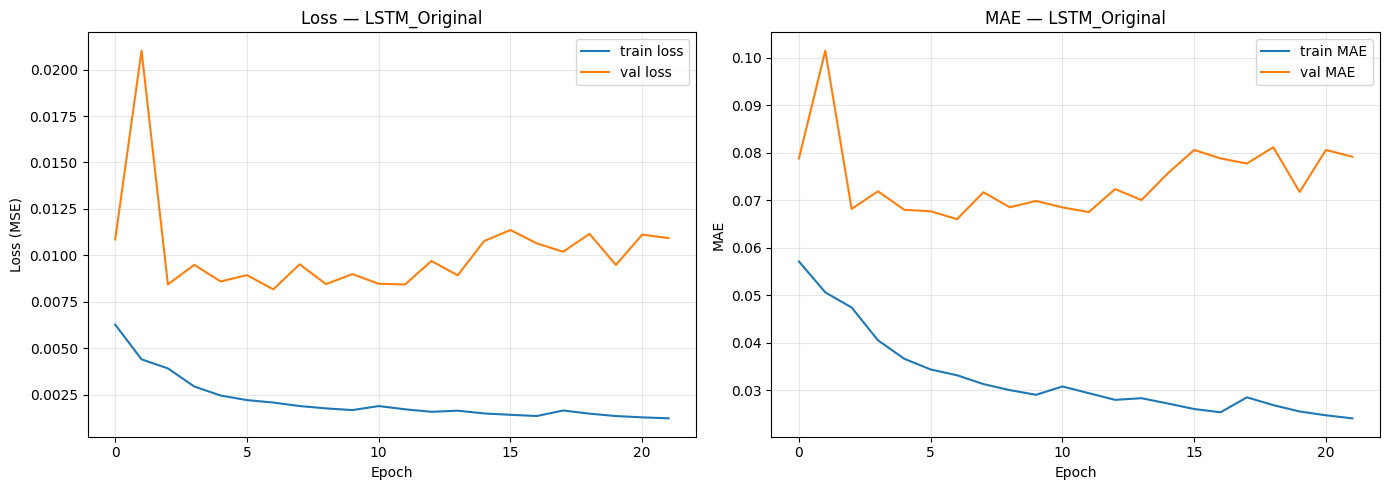

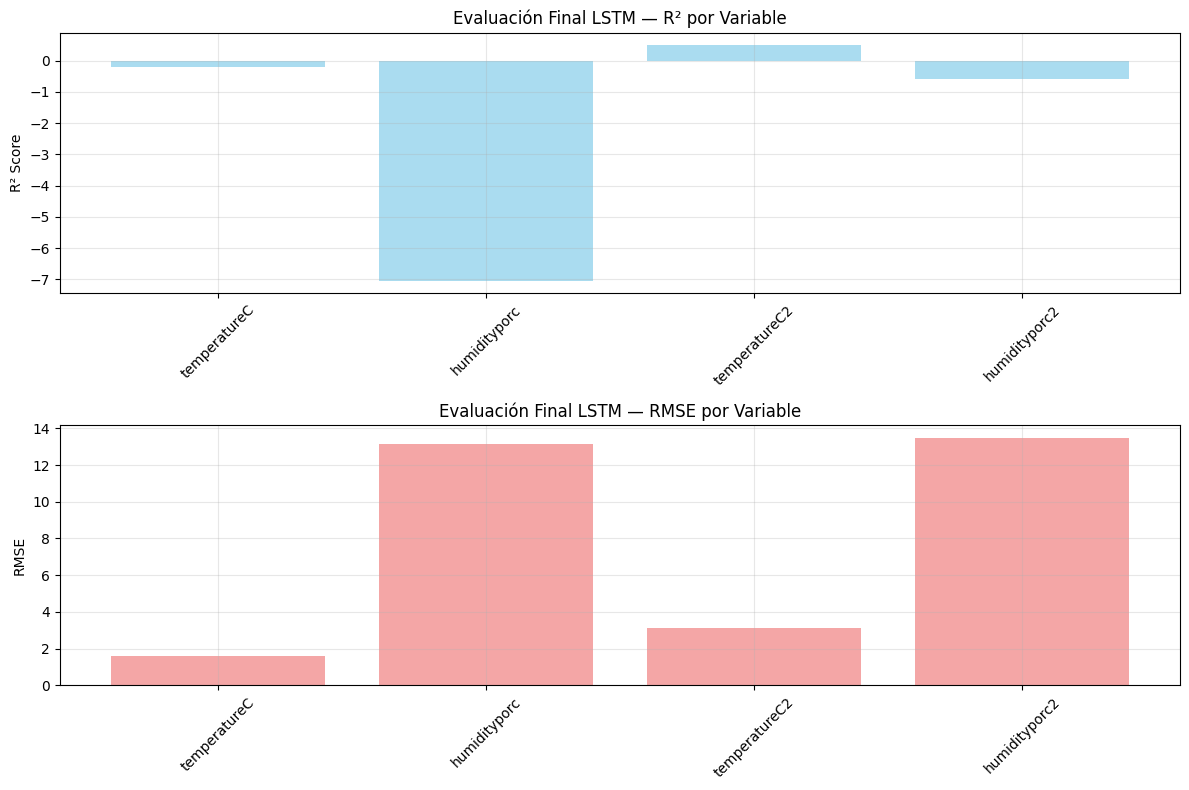

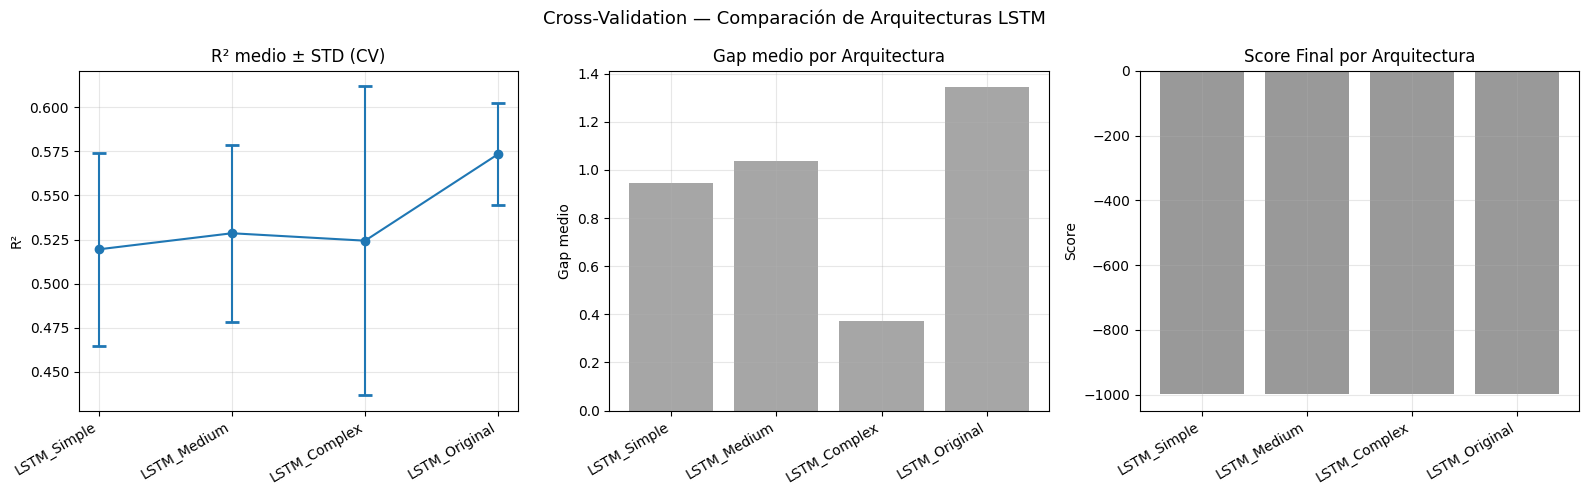

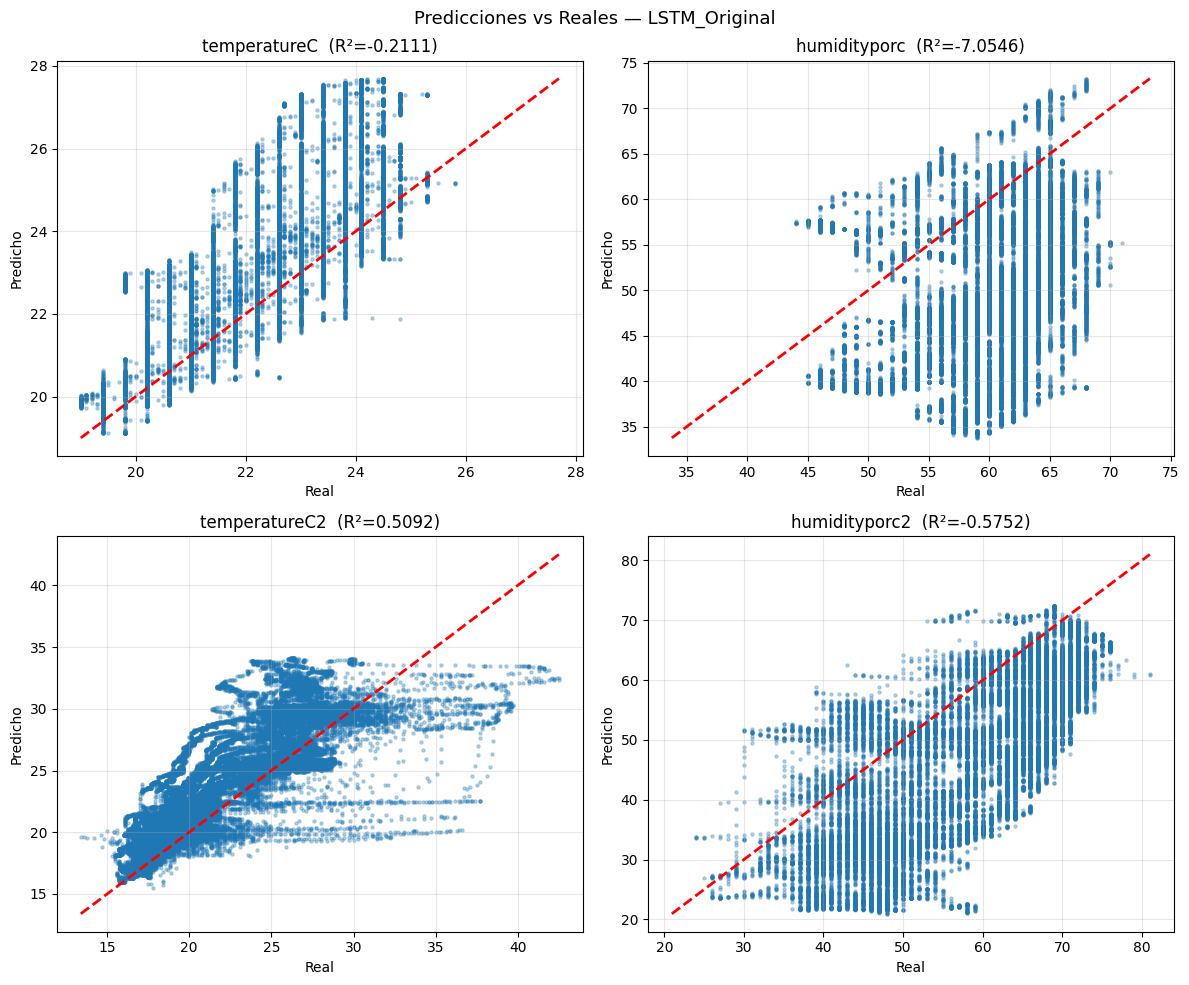


🎉 PROCESO LSTM COMPLETADO
✅ Seed fija aplicada:            SEED = 42
✅ Cross-validation:              3 folds
✅ Ranking de arquitecturas:      cv_logs/ranking_arquitecturas.txt
✅ Configuración seleccionada:    LSTM_Original
✅ Modelo guardado como:          '1yearbest_lstm_model.h5'
✅ Checkpoint:                    training_checkpoints/cp.weights.h5
✅ Log de entrenamiento (época):  training_logs/training_log.txt
✅ Métricas finales:              training_logs/final_metrics.txt
✅ Gráficas guardadas en:         training_logs/


In [2]:
import os
import random
import json
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Input, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, Callback
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ==============================
# 0. SEED GLOBAL PARA REPRODUCIBILIDAD
# ==============================

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ==============================
# 0.1 VERIFICAR GPU DISPONIBLE
# ==============================

print("=" * 60)
print("VERIFICACIÓN DE GPU")
print("=" * 60)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"✅ GPU detectada por TensorFlow: {gpus}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("⚠️  TensorFlow NO detecta GPU. Se usará CPU.")
    print("   Si usas Windows nativo con TF >= 2.11, instala:")
    print("   pip install tensorflow-cpu tensorflow-directml-plugin")
print("=" * 60)

# ==============================
# 1. CARGAR Y PREPARAR LOS DATOS
# ==============================

url = 'C:/Users/User/Desktop/4months/dataclean_4months.csv'
df = pd.read_csv(url)

print(f"Forma original del dataset: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")

if 'id' in df.columns:
    df = df.drop('id', axis=1)
    print("Columna 'id' eliminada")

df['date'] = pd.to_datetime(df['date'])

df['day']    = df['date'].dt.day
df['month']  = df['date'].dt.month
df['year']   = df['date'].dt.year
df['hour']   = df['hours']
df['minute'] = df['minutes']

df['datetime'] = pd.to_datetime(
    df['date'].astype(str) + ' ' + df['hours'].astype(str) + ':' + df['minutes'].astype(str),
    errors='coerce'
)
df.set_index('datetime', inplace=True)

# ==============================
# 2. DEFINIR FEATURES DE ENTRADA / SALIDA
# ==============================

input_features  = ['day', 'month', 'year', 'hours', 'minutes']
output_features = ['temperatureC', 'humidityporc', 'temperatureC2', 'humidityporc2']

scaler_input  = MinMaxScaler()
scaler_output = MinMaxScaler()

input_scaled  = scaler_input.fit_transform(df[input_features])
output_scaled = scaler_output.fit_transform(df[output_features])

# ==============================
# 3. CREAR SECUENCIAS
# ==============================

seq_length = 60
print(f"Sequence length: {seq_length}")

def create_sequences(input_data, output_data, seq_length):
    X_input, y = [], []
    for i in range(len(input_data) - seq_length):
        X_input.append(input_data[i:i + seq_length])
        y.append(output_data[i + seq_length])
    return np.array(X_input, dtype=np.float32), np.array(y, dtype=np.float32)

X_input, y = create_sequences(input_scaled, output_scaled, seq_length)

print(f"Shape X_input: {X_input.shape}")
print(f"Shape y:       {y.shape}")

# ==============================
# 4. DIVISIÓN TEMPORAL 80 / 20
# ==============================

split_point = int(len(X_input) * 0.8)

X_dev,        y_dev        = X_input[:split_point], y[:split_point]
X_test_final, y_test_final = X_input[split_point:], y[split_point:]

print(f"Datos para desarrollo (train+val): {len(X_dev)}")
print(f"Datos para test final:             {len(X_test_final)}")

# ==============================
# 5. CONFIGURACIONES A COMPARAR — LSTM
# ==============================

model_configs = {
    'LSTM_Simple': {
        'lstm_units': 32,
        'dense_layers': [16],
        'dropout': 0.1,
        'learning_rate': 0.001,
        'return_sequences': False,
    },
    'LSTM_Medium': {
        'lstm_units': 64,
        'dense_layers': [32],
        'dropout': 0.2,
        'learning_rate': 0.001,
        'return_sequences': False,
    },
    'LSTM_Complex': {
        'lstm_units': 128,
        'lstm_units_2': 64,
        'dense_layers': [32, 16],
        'dropout': 0.3,
        'learning_rate': 0.001,
        'return_sequences': True,
    },
    'LSTM_Original': {
        'lstm_units': 64,
        'dense_layers': [32],
        'dropout': 0.0,
        'learning_rate': 0.001,
        'return_sequences': False,
    },
}

# ==============================
# 6. FUNCIÓN PARA CREAR EL MODELO LSTM
# ==============================

def create_lstm_model(input_shape, output_dim, config):
    model = Sequential()
    model.add(Input(shape=input_shape))

    if config.get('return_sequences', False):
        model.add(LSTM(config['lstm_units'], return_sequences=True))
        if config.get('dropout', 0) > 0:
            model.add(Dropout(config['dropout']))
        model.add(LSTM(config.get('lstm_units_2', 32)))
    else:
        model.add(LSTM(config['lstm_units']))

    if config.get('dropout', 0) > 0:
        model.add(Dropout(config['dropout']))

    for dense_units in config.get('dense_layers', []):
        model.add(Dense(dense_units, activation='relu'))
        if config.get('dropout', 0) > 0:
            model.add(Dropout(config['dropout']))

    model.add(Dense(output_dim))

    model.compile(
        optimizer=Adam(learning_rate=config.get('learning_rate', 0.001)),
        loss='mse',
        metrics=['mae'],
    )
    return model

# ==============================
# 7. CALLBACKS PERSONALIZADOS
# ==============================

class EpochTrainingLogger(Callback):
    """
    Guarda el historial de entrenamiento época por época en un .txt.
    Formato idéntico al que imprime Keras en consola:
        Epoch 92: loss=0.0034 | mae=0.0421 | val_loss=0.0199 | val_mae=0.1027
    Soporta append para reanudación de entrenamiento.
    """
    def __init__(self, log_path, config_name, fold=None):
        super().__init__()
        self.log_path    = log_path
        self.config_name = config_name
        self.fold        = fold

    def on_train_begin(self, logs=None):
        write_header = (
            not os.path.exists(self.log_path)
            or os.path.getsize(self.log_path) == 0
        )
        if write_header:
            fold_str = f" | Fold {self.fold}" if self.fold is not None else ""
            with open(self.log_path, 'w', encoding='utf-8') as f:
                f.write("=" * 80 + "\n")
                f.write(f"TRAINING LOG — {self.config_name}{fold_str}\n")
                f.write(f"Fecha inicio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
                f.write("=" * 80 + "\n")
                f.write(
                    f"{'Epoch':<10} {'loss':<14} {'mae':<14} "
                    f"{'val_loss':<14} {'val_mae':<14}\n"
                )
                f.write("-" * 80 + "\n")

    def on_epoch_end(self, epoch, logs=None):
        logs     = logs or {}
        loss     = logs.get('loss',     float('nan'))
        mae      = logs.get('mae',      float('nan'))
        val_loss = logs.get('val_loss', float('nan'))
        val_mae  = logs.get('val_mae',  float('nan'))

        line = (
            f"Epoch {epoch + 1:<5} "
            f"loss={loss:.6f}  "
            f"mae={mae:.6f}  "
            f"val_loss={val_loss:.6f}  "
            f"val_mae={val_mae:.6f}\n"
        )
        with open(self.log_path, 'a', encoding='utf-8') as f:
            f.write(line)

    def on_train_end(self, logs=None):
        with open(self.log_path, 'a', encoding='utf-8') as f:
            f.write("-" * 80 + "\n")
            f.write(
                f"Entrenamiento finalizado: "
                f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n"
            )
            f.write("=" * 80 + "\n\n")


class SaveEpochCallback(Callback):
    """Persiste el número del último epoch completado para poder reanudar."""
    def __init__(self, epoch_path):
        super().__init__()
        self.epoch_path = epoch_path

    def on_epoch_end(self, epoch, logs=None):
        with open(self.epoch_path, 'w') as f:
            f.write(str(epoch + 1))

# ==============================
# 8. MÉTRICAS POR VARIABLE
# ==============================

def compute_metrics_per_variable(y_true_orig, y_pred_orig, output_cols):
    """
    Calcula MSE, RMSE, MAE, MAPE, R², Correlación, STD por cada variable de salida.
    Espera arrays en espacio original (sin escalar).
    """
    metrics = {}
    for i, col in enumerate(output_cols):
        mse         = mean_squared_error(y_true_orig[:, i], y_pred_orig[:, i])
        rmse        = np.sqrt(mse)
        mae         = mean_absolute_error(y_true_orig[:, i], y_pred_orig[:, i])
        r2          = r2_score(y_true_orig[:, i], y_pred_orig[:, i])
        correlation = np.corrcoef(y_true_orig[:, i], y_pred_orig[:, i])[0, 1]
        std_true    = float(np.std(y_true_orig[:, i]))
        std_pred    = float(np.std(y_pred_orig[:, i]))

        mask = np.abs(y_true_orig[:, i]) > 1e-8
        mape = (
            np.mean(
                np.abs(
                    (y_true_orig[:, i][mask] - y_pred_orig[:, i][mask])
                    / (y_true_orig[:, i][mask] + 1e-8)
                )
            ) * 100
            if mask.sum() > 0 else 0.0
        )
        metrics[col] = dict(
            MSE=mse, RMSE=rmse, MAE=mae, MAPE=mape,
            R2=r2, Correlation=correlation,
            STD_true=std_true, STD_pred=std_pred,
        )
    return metrics


def aggregate_metrics(per_variable_metrics):
    """
    Colapsa las métricas por variable en escalares para CV scoring:
    mean_R2, std_R2, mean_MAE, mean_MAPE.
    """
    r2_list   = [m['R2']   for m in per_variable_metrics.values()]
    mae_list  = [m['MAE']  for m in per_variable_metrics.values()]
    mape_list = [m['MAPE'] for m in per_variable_metrics.values()]
    return dict(
        mean_R2=float(np.mean(r2_list)),
        std_R2=float(np.std(r2_list)),
        mean_MAE=float(np.mean(mae_list)),
        mean_MAPE=float(np.mean(mape_list)),
    )

# ==============================
# 9. DIRECTORIOS DE TRABAJO
# ==============================

os.makedirs("cv_logs",              exist_ok=True)
os.makedirs("cv_checkpoints",       exist_ok=True)
os.makedirs("training_logs",        exist_ok=True)
os.makedirs("training_checkpoints", exist_ok=True)

# ==============================
# 10. CROSS-VALIDATION TEMPORAL 
# ==============================

N_FOLDS     = 3      # <-- cambia aquí si quieres otro número de folds
CV_EPOCHS   = 30      # épocas por fold (liviano para CV)
CV_PATIENCE = 7
BATCH_SIZE  = 32

CV_PROGRESS_FILE = "cv_logs/cv_progress.json"


def load_cv_progress():
    if os.path.exists(CV_PROGRESS_FILE):
        with open(CV_PROGRESS_FILE, 'r') as f:
            return json.load(f)
    return {}


class NumpyEncoder(json.JSONEncoder):
    """Convierte tipos NumPy a tipos nativos de Python para poder serializar con json."""
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)


def save_cv_progress(progress):
    with open(CV_PROGRESS_FILE, 'w') as f:
        json.dump(progress, f, indent=2, cls=NumpyEncoder)


def temporal_kfold_indices(n_samples, n_folds):
    """
    Expanding-window CV temporal.
    Fold i  →  train = [0 .. fold_size*(i+1))   val = [fold_size*(i+1) .. fold_size*(i+2))
    """
    fold_size = n_samples // (n_folds + 1)
    splits = []
    for i in range(n_folds):
        train_end = fold_size * (i + 1)
        val_start = train_end
        val_end   = min(val_start + fold_size, n_samples)
        if val_end > val_start and train_end > 0:
            splits.append(
                (np.arange(0, train_end), np.arange(val_start, val_end))
            )
    return splits


cv_progress = load_cv_progress()
cv_results  = {}   # { config_name: { fold_metrics: [...], ... } }

print("\n" + "=" * 70)
print(f"CROSS-VALIDATION TEMPORAL — {N_FOLDS} FOLDS")
print("=" * 70)

fold_splits = temporal_kfold_indices(len(X_dev), N_FOLDS)

for config_name, config in model_configs.items():

    print(f"\n{'─' * 60}")
    print(f"  Arquitectura: {config_name}")
    print(f"{'─' * 60}")

    cv_arch_log       = f"cv_logs/cv_{config_name}.txt"
    fold_metrics_list = []

    # ── Cargar progreso previo (reanudación) ──
    prev_folds = cv_progress.get(config_name, {}).get('fold_metrics', [])
    start_fold = len(prev_folds)

    if start_fold > 0:
        fold_metrics_list = prev_folds
        print(f"  📌 Reanudando desde fold {start_fold + 1} (ya completados: {start_fold})")
    else:
        with open(cv_arch_log, 'a', encoding='utf-8') as f:
            f.write("=" * 80 + "\n")
            f.write(f"CV LOG — {config_name} — {N_FOLDS} folds\n")
            f.write(f"Fecha inicio: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
            f.write("=" * 80 + "\n\n")
            f.write(
                f"{'Fold':<8} {'mean_R2':<12} {'std_R2':<12} "
                f"{'mean_MAE':<12} {'Gap':<12} {'Val_MAE_last':<14}\n"
            )
            f.write("-" * 80 + "\n")

    for fold_idx, (train_idx, val_idx) in enumerate(fold_splits):

        if fold_idx < start_fold:
            continue   # ya procesado

        fold_num = fold_idx + 1
        print(
            f"\n  ► Fold {fold_num}/{N_FOLDS} | "
            f"train={len(train_idx)} | val={len(val_idx)}"
        )

        X_tr, y_tr   = X_dev[train_idx], y_dev[train_idx]
        X_val, y_val = X_dev[val_idx],   y_dev[val_idx]

        # Rutas de checkpoint / epoch / log para este fold
        ckpt_fold  = f"cv_checkpoints/{config_name}_fold{fold_num}.weights.h5"
        epoch_fold = f"cv_checkpoints/{config_name}_fold{fold_num}_epoch.txt"
        fold_log   = f"cv_logs/training_{config_name}_fold{fold_num}.txt"

        # Crear modelo
        tf.random.set_seed(SEED + fold_idx)
        model = create_lstm_model(
            input_shape=(X_dev.shape[1], X_dev.shape[2]),
            output_dim=len(output_features),
            config=config,
        )

        # Cargar pesos previos si existen (reanudación dentro del fold)
        initial_epoch_fold = 0
        if os.path.exists(epoch_fold):
            with open(epoch_fold, 'r') as f:
                initial_epoch_fold = int(f.read().strip())
        if os.path.exists(ckpt_fold) and initial_epoch_fold > 0:
            try:
                model.load_weights(ckpt_fold)
                print(f"    ✅ Pesos cargados (epoch {initial_epoch_fold}). Continuando...")
            except Exception as e:
                print(f"    ⚠️  Error al cargar pesos: {e}. Iniciando desde cero.")
                initial_epoch_fold = 0

        # Callbacks del fold
        cp_cb = ModelCheckpoint(
            filepath=ckpt_fold,
            save_weights_only=True,
            save_best_only=True,
            monitor='val_loss',
            verbose=0,
        )
        es_cb = EarlyStopping(
            monitor='val_loss',
            patience=CV_PATIENCE,
            restore_best_weights=True,
            verbose=0,
        )
        log_cb  = EpochTrainingLogger(fold_log, config_name, fold=fold_num)
        save_ep = SaveEpochCallback(epoch_fold)

        # Entrenar fold
        hist = model.fit(
            X_tr, y_tr,
            validation_data=(X_val, y_val),
            epochs=CV_EPOCHS,
            initial_epoch=initial_epoch_fold,
            batch_size=BATCH_SIZE,
            verbose=1,
            callbacks=[cp_cb, es_cb, log_cb, save_ep],
        )

        # ── Métricas del fold en espacio original ──
        y_pred_s = model.predict(X_val, verbose=0)
        y_pred   = scaler_output.inverse_transform(y_pred_s)
        y_true   = scaler_output.inverse_transform(y_val)

        per_var = compute_metrics_per_variable(y_true, y_pred, output_features)
        agg     = aggregate_metrics(per_var)

        # Gap = (val_mae - train_mae) / train_mae   (última época)
        last_train_mae = hist.history['mae'][-1]
        last_val_mae   = hist.history['val_mae'][-1]
        gap = (last_val_mae - last_train_mae) / (last_train_mae + 1e-10)

        fold_summary = dict(
            fold=fold_num,
            mean_R2=agg['mean_R2'],
            std_R2=agg['std_R2'],
            mean_MAE=agg['mean_MAE'],
            mean_MAPE=agg['mean_MAPE'],
            gap=gap,
            train_mae_last=last_train_mae,
            val_mae_last=last_val_mae,
            per_variable=per_var,
        )
        fold_metrics_list.append(fold_summary)

        # Guardar progreso (para reanudación)
        cv_progress[config_name] = {'fold_metrics': fold_metrics_list}
        save_cv_progress(cv_progress)

        # Escribir métricas del fold en log de CV (resumen tabular)
        with open(cv_arch_log, 'a', encoding='utf-8') as f:
            f.write(
                f"Fold {fold_num:<4} "
                f"{agg['mean_R2']:<12.6f} "
                f"{agg['std_R2']:<12.6f} "
                f"{agg['mean_MAE']:<12.6f} "
                f"{gap:<12.6f} "
                f"{last_val_mae:<14.6f}\n"
            )
            # Detalle por variable
            for col, m in per_var.items():
                f.write(
                    f"         [{col}] R²={m['R2']:.4f} | "
                    f"MAE={m['MAE']:.4f} | RMSE={m['RMSE']:.4f} | "
                    f"MAPE={m['MAPE']:.2f}% | Corr={m['Correlation']:.4f}\n"
                )
            f.write("\n")

        print(
            f"    Fold {fold_num} — R²={agg['mean_R2']:.4f} | "
            f"MAE={agg['mean_MAE']:.4f} | STD_R²={agg['std_R2']:.4f} | "
            f"Gap={gap:.4f} | Val_MAE={last_val_mae:.6f}"
        )

    # ── Estadísticas agregadas de todos los folds ──
    r2_vals   = [fm['mean_R2']  for fm in fold_metrics_list]
    mae_vals  = [fm['mean_MAE'] for fm in fold_metrics_list]
    std_vals  = [fm['std_R2']   for fm in fold_metrics_list]
    gap_vals  = [fm['gap']      for fm in fold_metrics_list]

    cv_results[config_name] = dict(
        r2_mean=float(np.mean(r2_vals)),
        r2_std=float(np.std(r2_vals)),
        mae_mean=float(np.mean(mae_vals)),
        mae_std=float(np.std(mae_vals)),
        std_r2_mean=float(np.mean(std_vals)),
        gap_mean=float(np.mean(gap_vals)),
        fold_metrics=fold_metrics_list,
    )

    agg_r2  = cv_results[config_name]['r2_mean']
    agg_std = cv_results[config_name]['std_r2_mean']
    agg_mae = cv_results[config_name]['mae_mean']
    agg_gap = cv_results[config_name]['gap_mean']

    # Escribir resumen agregado al log de CV
    with open(cv_arch_log, 'a', encoding='utf-8') as f:
        f.write("=" * 80 + "\n")
        f.write(f"RESUMEN AGREGADO — {config_name}\n")
        f.write(f"  Promedio R²:       {agg_r2:.6f}\n")
        f.write(f"  STD(R²):           {agg_std:.6f}\n")
        f.write(f"  Promedio MAE:      {agg_mae:.6f}\n")
        f.write(f"  Promedio Gap:      {agg_gap:.6f}\n")
        f.write(f"  Fecha fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write("=" * 80 + "\n\n")

    print(
        f"\n  ✅ {config_name} completado — "
        f"R²={agg_r2:.4f} | STD={agg_std:.4f} | "
        f"MAE={agg_mae:.4f} | Gap={agg_gap:.4f}"
    )

# ==============================
# 11. SCORING Y RANKING DE ARQUITECTURAS
# ==============================

print("\n" + "=" * 70)
print("SCORING Y RANKING DE ARQUITECTURAS")
print("=" * 70)

RANKING_LOG = "cv_logs/ranking_arquitecturas.txt"

names   = list(cv_results.keys())
r2_arr  = np.array([cv_results[n]['r2_mean']    for n in names])
mae_arr = np.array([cv_results[n]['mae_mean']   for n in names])
std_arr = np.array([cv_results[n]['std_r2_mean'] for n in names])
gap_arr = np.array([cv_results[n]['gap_mean']   for n in names])

# ── Filtros mínimos ──
FILTER_MIN_R2  = 0.20
FILTER_MAX_GAP = 1.80
FILTER_MAX_STD = 0.15

eligible_mask = (
    (r2_arr  >= FILTER_MIN_R2)
    & (gap_arr <= FILTER_MAX_GAP)
    & (std_arr <= FILTER_MAX_STD)
)


def minmax_norm(arr):
    rng = arr.max() - arr.min()
    if rng == 0:
        return np.zeros_like(arr, dtype=float)
    return (arr - arr.min()) / rng


r2_norm  = minmax_norm(r2_arr)
mae_norm = minmax_norm(mae_arr)
std_norm = minmax_norm(std_arr)
gap_norm = minmax_norm(gap_arr)

# Score = 0.40*R2_norm + 0.30*(1-MAE_norm) + 0.20*(1-STD_norm) + 0.10*(1-Gap_norm)
scores = (
    0.40 * r2_norm
    + 0.30 * (1 - mae_norm)
    + 0.20 * (1 - std_norm)
    + 0.10 * (1 - gap_norm)
)

# Penalizar arquitecturas que no superan los filtros
scores_filtered = np.where(eligible_mask, scores, -999.0)
ranking_order   = np.argsort(scores_filtered)[::-1]

with open(RANKING_LOG, 'w', encoding='utf-8') as f:
    f.write("=" * 90 + "\n")
    f.write("RANKING DE ARQUITECTURAS LSTM — CROSS-VALIDATION\n")
    f.write(f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(
        f"N_FOLDS={N_FOLDS} | FILTROS: R²≥{FILTER_MIN_R2} | "
        f"Gap≤{FILTER_MAX_GAP} | STD≤{FILTER_MAX_STD}\n"
    )
    f.write("=" * 90 + "\n")
    f.write(
        f"{'Pos':<5} {'Arquitectura':<22} {'R²_mean':<12} {'STD_R²':<12} "
        f"{'MAE_mean':<12} {'Gap_mean':<12} {'Score':<10} {'Estado'}\n"
    )
    f.write("-" * 90 + "\n")

    for pos, idx in enumerate(ranking_order):
        n    = names[idx]
        elig = "✅ ELEGIBLE" if eligible_mask[idx] else "❌ DESCARTADA"
        line = (
            f"{pos + 1:<5} {n:<22} {r2_arr[idx]:<12.6f} {std_arr[idx]:<12.6f} "
            f"{mae_arr[idx]:<12.6f} {gap_arr[idx]:<12.6f} "
            f"{scores_filtered[idx]:<10.6f} {elig}\n"
        )
        f.write(line)
        print(line, end='')

    f.write("\n" + "=" * 90 + "\n")
    f.write("\nDETALLE POR ARQUITECTURA:\n\n")

    for idx in ranking_order:
        n    = names[idx]
        elig = eligible_mask[idx]
        f.write(
            f"  [{n}]  Score={scores_filtered[idx]:.6f}  "
            f"{'ELEGIBLE' if elig else 'DESCARTADA'}\n"
        )
        f.write(f"    Promedio R²:   {r2_arr[idx]:.6f}\n")
        f.write(f"    STD(R²):       {std_arr[idx]:.6f}\n")
        f.write(f"    Promedio MAE:  {mae_arr[idx]:.6f}\n")
        f.write(f"    Promedio Gap:  {gap_arr[idx]:.6f}\n")
        for col in output_features:
            r2_folds  = [fm['per_variable'][col]['R2']  for fm in cv_results[n]['fold_metrics']]
            mae_folds = [fm['per_variable'][col]['MAE'] for fm in cv_results[n]['fold_metrics']]
            f.write(
                f"    [{col}] R²={np.mean(r2_folds):.4f}±{np.std(r2_folds):.4f} "
                f"| MAE={np.mean(mae_folds):.4f}±{np.std(mae_folds):.4f}\n"
            )
        f.write("\n")

    f.write("=" * 90 + "\n")

print(f"\n✅ Ranking guardado en: {RANKING_LOG}")

# ── Seleccionar mejor configuración ──
best_idx = None
for idx in ranking_order:
    if eligible_mask[idx]:
        best_idx = idx
        break

if best_idx is None:
    print("⚠️  Ninguna arquitectura superó todos los filtros. Se usa la de mayor R².")
    best_idx = int(np.argmax(r2_arr))

best_config_name = names[best_idx]
best_config      = model_configs[best_config_name]

print(f"\n🏆 Mejor arquitectura seleccionada: {best_config_name}")
print(
    f"   Score={scores_filtered[best_idx]:.6f} | R²={r2_arr[best_idx]:.4f} | "
    f"MAE={mae_arr[best_idx]:.4f} | Gap={gap_arr[best_idx]:.4f}"
)

# ==============================
# 12. RUTAS DE ARCHIVOS — ENTRENAMIENTO FINAL
# ==============================

checkpoint_path   = "training_checkpoints/cp.weights.h5"
epoch_path        = "training_checkpoints/last_epoch.txt"
training_log_path = "training_logs/training_log.txt"
metrics_path      = "training_logs/final_metrics.txt"

FINAL_EPOCHS   = 100
FINAL_PATIENCE = 15

# ==============================
# 13. CREAR MODELO FINAL Y CARGAR CHECKPOINT SI EXISTE
# ==============================

print("\n" + "=" * 60)
print(f"ENTRENANDO MODELO LSTM FINAL — {best_config_name}")
print("=" * 60)

tf.random.set_seed(SEED)

val_split_dev = int(len(X_dev) * 0.8)
X_train_final, X_val_final = X_dev[:val_split_dev],  X_dev[val_split_dev:]
y_train_final, y_val_final = y_dev[:val_split_dev],  y_dev[val_split_dev:]

final_lstm_model = create_lstm_model(
    input_shape=(X_dev.shape[1], X_dev.shape[2]),
    output_dim=len(output_features),
    config=best_config,
)
final_lstm_model.summary()

initial_epoch = 0

if os.path.exists(epoch_path):
    with open(epoch_path, 'r') as f:
        initial_epoch = int(f.read().strip())
    print(f"📌 Último epoch guardado: {initial_epoch}")

if os.path.exists(checkpoint_path) and initial_epoch > 0:
    try:
        final_lstm_model.load_weights(checkpoint_path)
        print(f"✅ Pesos cargados desde: {checkpoint_path}")
        print(f"🔄 Continuando desde epoch {initial_epoch + 1} hasta {FINAL_EPOCHS}...")
    except Exception as e:
        print(f"⚠️  Error al cargar pesos: {e}. Iniciando desde cero.")
        initial_epoch = 0
else:
    print("🆕 No se encontraron checkpoints previos. Iniciando desde cero.")
    initial_epoch = 0

# ==============================
# 14. CALLBACKS DEL ENTRENAMIENTO FINAL
# ==============================

cp_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,
    verbose=1,
    save_best_only=False,
    monitor='val_loss',
)

es_callback = EarlyStopping(
    monitor='val_loss',
    patience=FINAL_PATIENCE,
    restore_best_weights=True,
    verbose=1,
)

log_callback = EpochTrainingLogger(
    log_path=training_log_path,
    config_name=best_config_name,
    fold=None,
)

save_epoch_cb = SaveEpochCallback(epoch_path)

# ==============================
# 15. ENTRENAR MODELO FINAL
# ==============================

history = final_lstm_model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val_final, y_val_final),
    epochs=FINAL_EPOCHS,
    initial_epoch=initial_epoch,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=[cp_callback, es_callback, log_callback, save_epoch_cb],
)

# Guardar modelo completo
final_lstm_model.save('4monthsbest_lstm_model.h5')
print(f"\n✅ Modelo completo guardado como '4monthsbest_lstm_model.h5'")
print(f"✅ Checkpoint guardado en:        {checkpoint_path}")
print(f"✅ Log de entrenamiento en:       {training_log_path}")

# ==============================
# 16. EVALUACIÓN FINAL EN TEST SET
# ==============================

print("\n" + "=" * 60)
print("EVALUACIÓN FINAL EN TEST SET")
print("=" * 60)

y_pred_scaled = final_lstm_model.predict(X_test_final, verbose=0)
y_pred        = scaler_output.inverse_transform(y_pred_scaled)
y_true        = scaler_output.inverse_transform(y_test_final)

print(f"Tamaño del conjunto de prueba final: {len(y_test_final)}")

# ==============================
# 17. CALCULAR Y GUARDAR MÉTRICAS FINALES
# ==============================

all_train_loss = history.history['loss']
all_val_loss   = history.history['val_loss']
all_train_mae  = history.history['mae']
all_val_mae    = history.history['val_mae']

last_train_loss = all_train_loss[-1]
last_val_loss   = all_val_loss[-1]
last_train_mae_ = all_train_mae[-1]
last_val_mae_   = all_val_mae[-1]

# Gap = (val_loss - train_loss) / train_loss
gap = (last_val_loss - last_train_loss) / (last_train_loss + 1e-10)

std_val_loss   = float(np.std(all_val_loss))
std_train_loss = float(np.std(all_train_loss))

# Métricas por variable (espacio original)
per_variable_metrics = compute_metrics_per_variable(y_true, y_pred, output_features)

for target, m in per_variable_metrics.items():
    print(f"\n{target}:")
    print(f"  MSE:         {m['MSE']:.4f}")
    print(f"  RMSE:        {m['RMSE']:.4f}")
    print(f"  MAE:         {m['MAE']:.4f}")
    print(f"  MAPE:        {m['MAPE']:.4f}%")
    print(f"  R²:          {m['R2']:.4f}")
    print(f"  Correlación: {m['Correlation']:.4f}")
    print(f"  STD (real):  {m['STD_true']:.4f}")
    print(f"  STD (pred):  {m['STD_pred']:.4f}")

# Escribir archivo de métricas finales
with open(metrics_path, 'w', encoding='utf-8') as f:
    f.write("=" * 70 + "\n")
    f.write(f"MÉTRICAS FINALES — {best_config_name}\n")
    f.write(f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 70 + "\n\n")

    # ── Métricas globales del entrenamiento ──
    f.write("── MÉTRICAS GLOBALES DEL ENTRENAMIENTO ──\n")
    f.write(f"  Épocas entrenadas:         {len(all_train_loss)}\n")
    f.write(f"  Train Loss (última época): {last_train_loss:.6f}\n")
    f.write(f"  Val Loss   (última época): {last_val_loss:.6f}\n")
    f.write(f"  Train MAE  (última época): {last_train_mae_:.6f}\n")
    f.write(f"  Val MAE    (última época): {last_val_mae_:.6f}\n\n")

    f.write("  Gap (indicador de overfitting):\n")
    f.write("    Gap = (val_loss - train_loss) / train_loss\n")
    f.write(
        f"    Gap = ({last_val_loss:.6f} - {last_train_loss:.6f}) "
        f"/ {last_train_loss:.6f}\n"
    )
    f.write(f"    Gap = {gap:.6f}  ")
    if gap > 0.5:
        f.write("⚠️  ALTO → posible overfitting\n")
    elif gap > 0.2:
        f.write("⚡ MODERADO → revisar regularización\n")
    else:
        f.write("✅ BAJO → modelo generaliza bien\n")

    f.write(f"\n  STD de val_loss  (estabilidad): {std_val_loss:.6f}\n")
    f.write(f"  STD de train_loss:              {std_train_loss:.6f}\n\n")

    # ── Métricas por variable ──
    f.write("── MÉTRICAS POR VARIABLE (test set, espacio original) ──\n\n")
    for target, m in per_variable_metrics.items():
        f.write(f"  [{target}]\n")
        f.write(f"    R²:                {m['R2']:.6f}\n")
        f.write(f"    STD real:          {m['STD_true']:.6f}\n")
        f.write(f"    STD pred:          {m['STD_pred']:.6f}\n")
        f.write(f"    MAE (orig):        {m['MAE']:.6f}\n")
        f.write(f"    RMSE:              {m['RMSE']:.6f}\n")
        f.write(f"    MAPE:              {m['MAPE']:.4f}%\n")
        f.write(f"    Correlación:       {m['Correlation']:.6f}\n")
        f.write(f"    Val MAE (ult.ep.): {last_val_mae_:.6f}  (espacio escalado)\n")
        f.write(f"    Gap (global):      {gap:.6f}\n\n")

    # ── Resumen compacto ──
    f.write("── RESUMEN COMPACTO ──\n")
    f.write(
        f"{'Variable':<20} {'R²':>10} {'MAE':>10} {'RMSE':>10} "
        f"{'MAPE':>10} {'Corr':>10}\n"
    )
    f.write("-" * 70 + "\n")
    for target, m in per_variable_metrics.items():
        f.write(
            f"{target:<20} {m['R2']:>10.4f} {m['MAE']:>10.4f} "
            f"{m['RMSE']:>10.4f} {m['MAPE']:>9.2f}% {m['Correlation']:>10.4f}\n"
        )
    f.write("\n")
    f.write(f"  Gap global:   {gap:.6f}\n")
    f.write(f"  STD val_loss: {std_val_loss:.6f}\n")
    f.write("=" * 70 + "\n")
    f.write("FIN DEL REPORTE\n")
    f.write("=" * 70 + "\n")

print(f"\n✅ Métricas finales guardadas en: {metrics_path}")

# ==============================
# 18. VISUALIZACIONES
# ==============================

# ── A) Curvas de entrenamiento final ──
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(all_train_loss, label='train loss')
plt.plot(all_val_loss,   label='val loss')
plt.title(f'Loss — {best_config_name}')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(all_train_mae, label='train MAE')
plt.plot(all_val_mae,   label='val MAE')
plt.title(f'MAE — {best_config_name}')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_logs/curvas_entrenamiento_final.png', dpi=120, bbox_inches='tight')
plt.show()

# ── B) R² y RMSE por variable ──
final_r2_scores   = [per_variable_metrics[t]['R2']   for t in output_features]
final_rmse_scores = [per_variable_metrics[t]['RMSE'] for t in output_features]

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.bar(output_features, final_r2_scores, alpha=0.7, color='skyblue')
plt.ylabel('R² Score')
plt.title('Evaluación Final LSTM — R² por Variable')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.bar(output_features, final_rmse_scores, alpha=0.7, color='lightcoral')
plt.ylabel('RMSE')
plt.title('Evaluación Final LSTM — RMSE por Variable')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_logs/metricas_por_variable.png', dpi=120, bbox_inches='tight')
plt.show()

# ── C) Comparación CV entre arquitecturas ──
cfg_names = list(cv_results.keys())
r2_means  = [cv_results[n]['r2_mean'] for n in cfg_names]
r2_stds   = [cv_results[n]['r2_std']  for n in cfg_names]
gap_means = [cv_results[n]['gap_mean'] for n in cfg_names]
colors_bar = ['green' if eligible_mask[i] else 'gray' for i in range(len(names))]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Cross-Validation — Comparación de Arquitecturas LSTM', fontsize=13)

axes[0].errorbar(range(len(cfg_names)), r2_means, yerr=r2_stds,
                 marker='o', capsize=5, capthick=2)
axes[0].set_xticks(range(len(cfg_names)))
axes[0].set_xticklabels(cfg_names, rotation=30, ha='right')
axes[0].set_ylabel('R²')
axes[0].set_title('R² medio ± STD (CV)')
axes[0].grid(True, alpha=0.3)

axes[1].bar(cfg_names, gap_means, alpha=0.7, color=colors_bar)
axes[1].set_ylabel('Gap medio')
axes[1].set_title('Gap medio por Arquitectura')
axes[1].set_xticklabels(cfg_names, rotation=30, ha='right')
axes[1].grid(True, alpha=0.3)

axes[2].bar(names, scores_filtered, color=colors_bar, alpha=0.8)
axes[2].set_ylabel('Score')
axes[2].set_title('Score Final por Arquitectura')
axes[2].set_xticklabels(names, rotation=30, ha='right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_logs/comparacion_cv_arquitecturas.png', dpi=120, bbox_inches='tight')
plt.show()

# ── D) Pred vs Real ──
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f'Predicciones vs Reales — {best_config_name}', fontsize=13)

for i, target in enumerate(output_features):
    ax = axes[i // 2][i % 2]
    ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.3, s=5)
    lims = [
        min(y_true[:, i].min(), y_pred[:, i].min()),
        max(y_true[:, i].max(), y_pred[:, i].max()),
    ]
    ax.plot(lims, lims, 'r--', lw=2)
    ax.set_xlabel('Real')
    ax.set_ylabel('Predicho')
    ax.set_title(f'{target}  (R²={per_variable_metrics[target]["R2"]:.4f})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_logs/pred_vs_real.png', dpi=120, bbox_inches='tight')
plt.show()

# ==============================
# 19. RESUMEN FINAL EN CONSOLA
# ==============================

print(f"\n{'=' * 60}")
print(f"🎉 PROCESO LSTM COMPLETADO")
print(f"{'=' * 60}")
print(f"✅ Seed fija aplicada:            SEED = {SEED}")
print(f"✅ Cross-validation:              {N_FOLDS} folds")
print(f"✅ Ranking de arquitecturas:      {RANKING_LOG}")
print(f"✅ Configuración seleccionada:    {best_config_name}")
print(f"✅ Modelo guardado como:          '1yearbest_lstm_model.h5'")
print(f"✅ Checkpoint:                    {checkpoint_path}")
print(f"✅ Log de entrenamiento (época):  {training_log_path}")
print(f"✅ Métricas finales:              {metrics_path}")
print(f"✅ Gráficas guardadas en:         training_logs/")

In [3]:
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Define the predict_values function
def predict_values(date_str, hour, minute):
    date = datetime.strptime(date_str, '%Y-%m-%d')

    # Create a list to hold the input sequence for prediction
    input_sequence_pred = []

    # Generate the sequence of input features leading up to the prediction time
    current_datetime = datetime(date.year, date.month, date.day, hour, minute)
    for i in range(seq_length):
        # Calculate the datetime for each step in the sequence
        step_datetime = current_datetime - timedelta(minutes=(seq_length - 1 - i))

        # Create the input features for this step
        step_features = [step_datetime.day, step_datetime.month, step_datetime.year,
                        step_datetime.hour, step_datetime.minute]
        input_sequence_pred.append(step_features)

    # SOLUCIÓN: Convertir a DataFrame con nombres de columnas antes de escalar
    input_df = pd.DataFrame(input_sequence_pred, columns=input_features)
    input_sequence_scaled_pred = scaler_input.transform(input_df)

    # Reshape the input sequence for prediction
    X_pred_input = input_sequence_scaled_pred.reshape(1, seq_length, len(input_features))

    # Make prediction
    prediction_scaled = final_lstm_model.predict(X_pred_input, verbose=0)

    # SOLUCIÓN: Convertir predicción a DataFrame antes de inverse_transform
    prediction_df = pd.DataFrame(prediction_scaled, columns=output_features)
    prediction = scaler_output.inverse_transform(prediction_df)[0]
    return prediction

# Get user input for date, hours, and minutes
date_input = input("Enter the date (YYYY-MM-DD): ")
hours_input = int(input("Enter the hour (0-23): "))
minutes_input = int(input("Enter the minute (0-59): "))

# Use the predict_values function to get predictions
predicted_data = predict_values(date_input, hours_input, minutes_input)

# Print the predictions
print(f"\nPredicted data for {date_input} {hours_input:02d}:{minutes_input:02d}:")
for i, target in enumerate(output_features):
    print(f"  {target}: {predicted_data[i]:.4f}")


Predicted data for 2025-09-02 20:02:
  temperatureC: 24.5893
  humidityporc: 60.6232
  temperatureC2: 23.1970
  humidityporc2: 60.7177


Realizando predicciones para 121 puntos de tiempo...
Predicciones completadas!
Shape de predicciones: (121, 4)

Primeras 5 predicciones:
                     temperatureC  humidityporc  temperatureC2  humidityporc2
2025-09-02 20:02:00     24.589308     60.623158      23.197039      60.717735
2025-09-02 20:03:00     24.561611     60.718689      23.150946      60.812756
2025-09-02 20:04:00     24.535690     60.784142      23.119310      60.854427
2025-09-02 20:05:00     24.513014     60.827293      23.095732      60.868908
2025-09-02 20:06:00     24.493427     60.854626      23.077772      60.868317


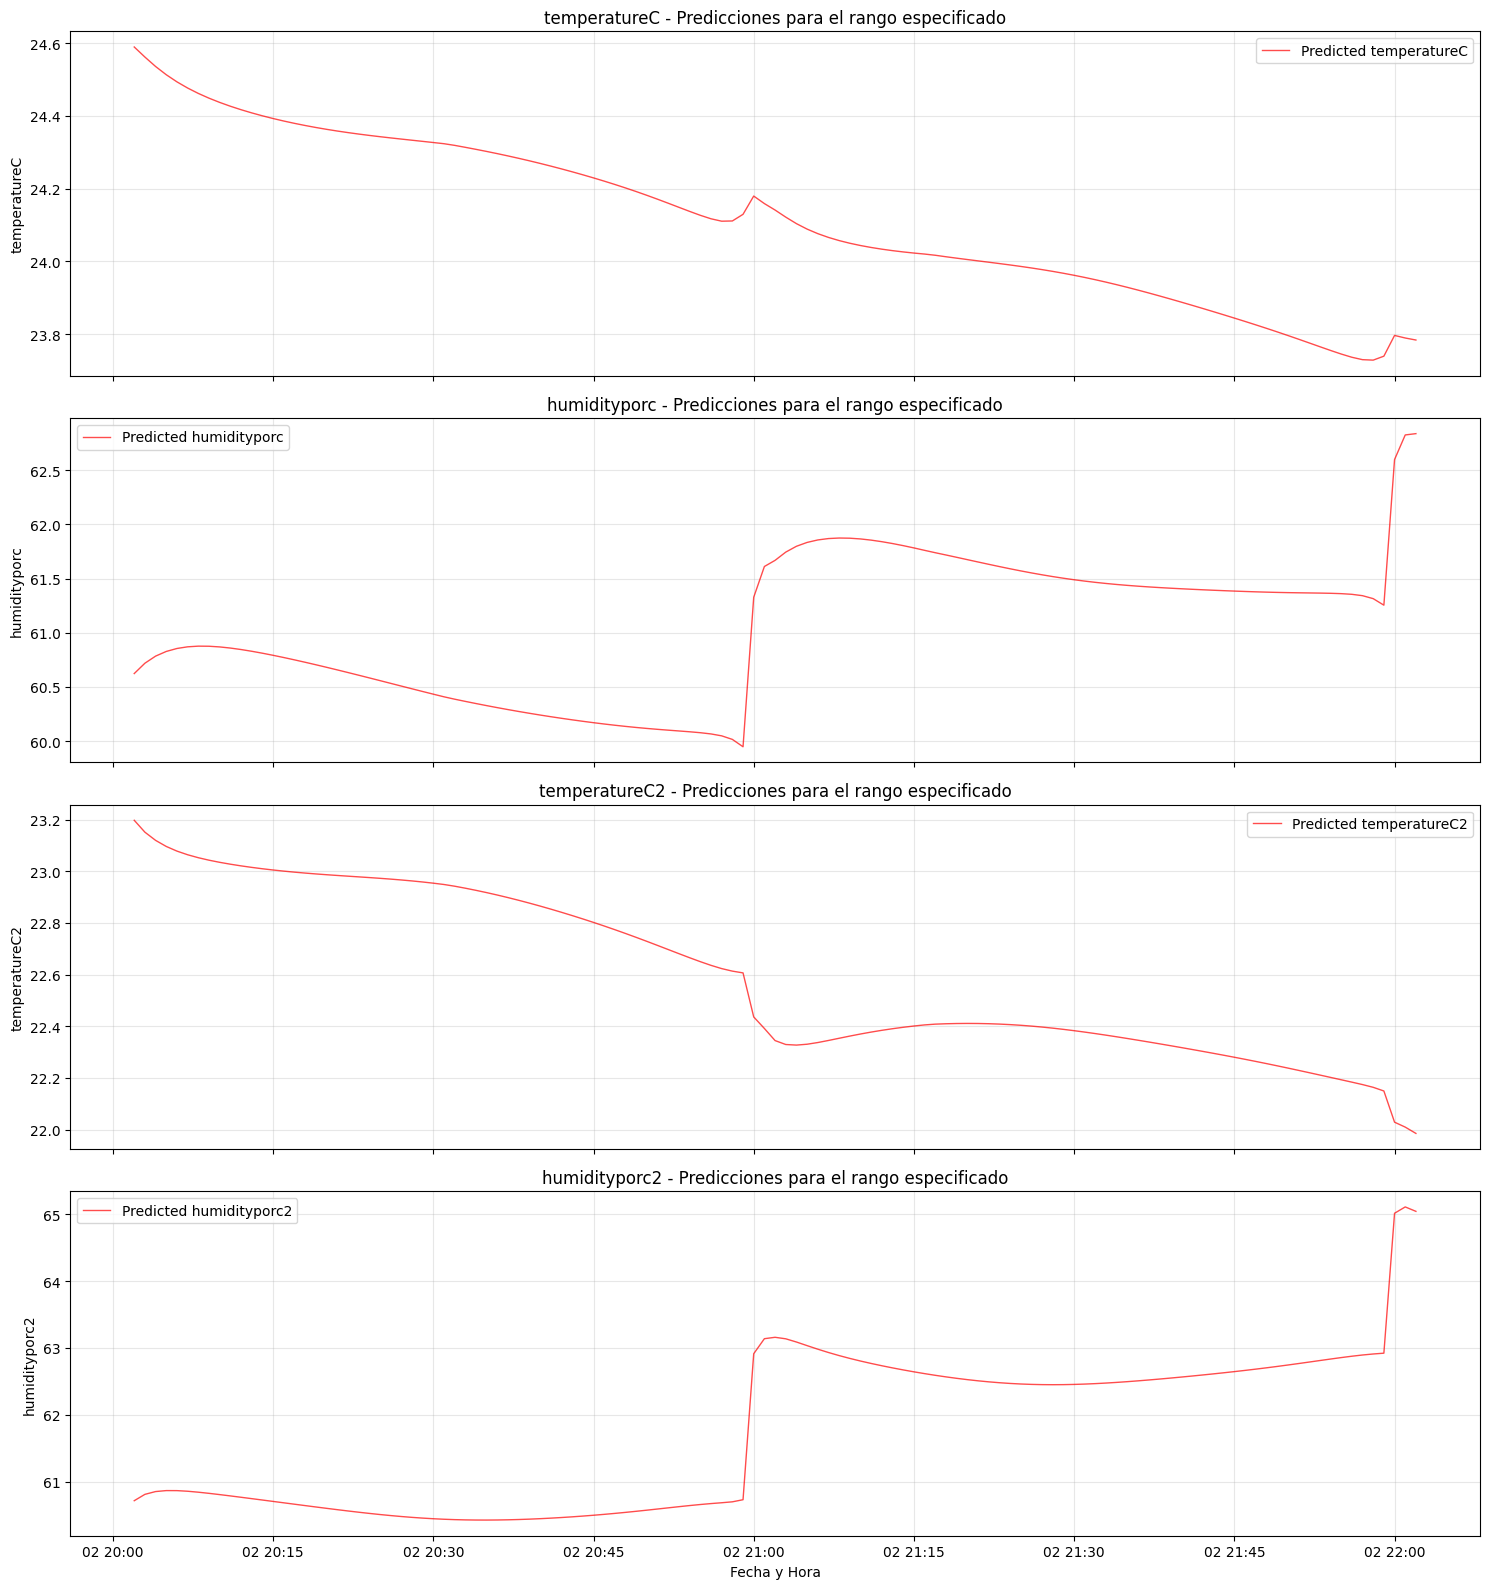


Estadísticas de las predicciones:

temperatureC:
  Mínimo: 23.73
  Máximo: 24.59
  Promedio: 24.12
  Desviación estándar: 0.22

humidityporc:
  Mínimo: 59.95
  Máximo: 62.84
  Promedio: 61.05
  Desviación estándar: 0.66

temperatureC2:
  Mínimo: 21.99
  Máximo: 23.20
  Promedio: 22.60
  Desviación estándar: 0.32

humidityporc2:
  Mínimo: 60.43
  Máximo: 65.11
  Promedio: 61.75
  Desviación estándar: 1.17


In [4]:
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# ==============================
# CÓDIGO MODIFICADO PARA RANGO DE PREDICCIONES
# ==============================

# Get user input for the start and end date and time
start_date_str = input("Enter the start date for prediction (YYYY-MM-DD): ")
start_hour = int(input("Enter the start hour for prediction (0-23): "))
start_minute = int(input("Enter the start minute for prediction (0-59): "))

end_date_str = input("Enter the end date for prediction (YYYY-MM-DD): ")
end_hour = int(input("Enter the end hour for prediction (0-23): "))
end_minute = int(input("Enter the end minute for prediction (0-59): "))

# Create datetime objects from user input
start_datetime = datetime.strptime(f"{start_date_str} {start_hour}:{start_minute}", '%Y-%m-%d %H:%M')
end_datetime = datetime.strptime(f"{end_date_str} {end_hour}:{end_minute}", '%Y-%m-%d %H:%M')

# Create a date range at minute frequency for prediction
dates_to_predict_range = pd.date_range(start=start_datetime, end=end_datetime, freq='min')

print(f"Realizando predicciones para {len(dates_to_predict_range)} puntos de tiempo...")

# Make predictions for the entire date range using your predict_values function
predictions_list = []
for dt in dates_to_predict_range:
    date_str = dt.strftime('%Y-%m-%d')
    hour = dt.hour
    minute = dt.minute

    # Use your predict_values function
    prediction = predict_values(date_str, hour, minute)
    predictions_list.append(prediction)

# Convert predictions to numpy array and then to DataFrame
predictions_array = np.array(predictions_list)
predictions_df = pd.DataFrame(
    predictions_array,
    index=dates_to_predict_range,
    columns=output_features  # Using your output_features variable
)

print("Predicciones completadas!")
print(f"Shape de predicciones: {predictions_df.shape}")
print("\nPrimeras 5 predicciones:")
print(predictions_df.head())

# ==============================
# VISUALIZACIÓN DE PREDICCIONES
# ==============================

# Plotting the predictions
fig, axes = plt.subplots(len(output_features), 1, figsize=(15, 4 * len(output_features)), sharex=True)

# Si solo hay un target, axes no será una lista
if len(output_features) == 1:
    axes = [axes]

for i, target in enumerate(output_features):
    axes[i].plot(predictions_df.index, predictions_df[target],
                label=f'Predicted {target}', color='red', alpha=0.7, linewidth=1)
    axes[i].set_title(f'{target} - Predicciones para el rango especificado')
    axes[i].set_ylabel(target)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Fecha y Hora')
plt.tight_layout()
plt.show()

# ==============================
# ESTADÍSTICAS ADICIONALES
# ==============================

print("\nEstadísticas de las predicciones:")
print("="*50)
for feature in output_features:
    print(f"\n{feature}:")
    print(f"  Mínimo: {predictions_df[feature].min():.2f}")
    print(f"  Máximo: {predictions_df[feature].max():.2f}")
    print(f"  Promedio: {predictions_df[feature].mean():.2f}")
    print(f"  Desviación estándar: {predictions_df[feature].std():.2f}")

# ==============================
# GUARDAR RESULTADOS (OPCIONAL)
# ==============================

# Uncomment the following lines if you want to save the predictions
# predictions_df.to_csv('predictions_range.csv')
# print("\nPredicciones guardadas en 'predictions_range.csv'")

Realizando predicciones para 61 puntos de tiempo...
Predicciones completadas!
Últimos datos reales: desde 2025-09-01 16:41:00 hasta 2025-09-01 20:00:00
Predicciones:         desde 2025-09-01 22:02:00 hasta 2025-09-01 23:02:00


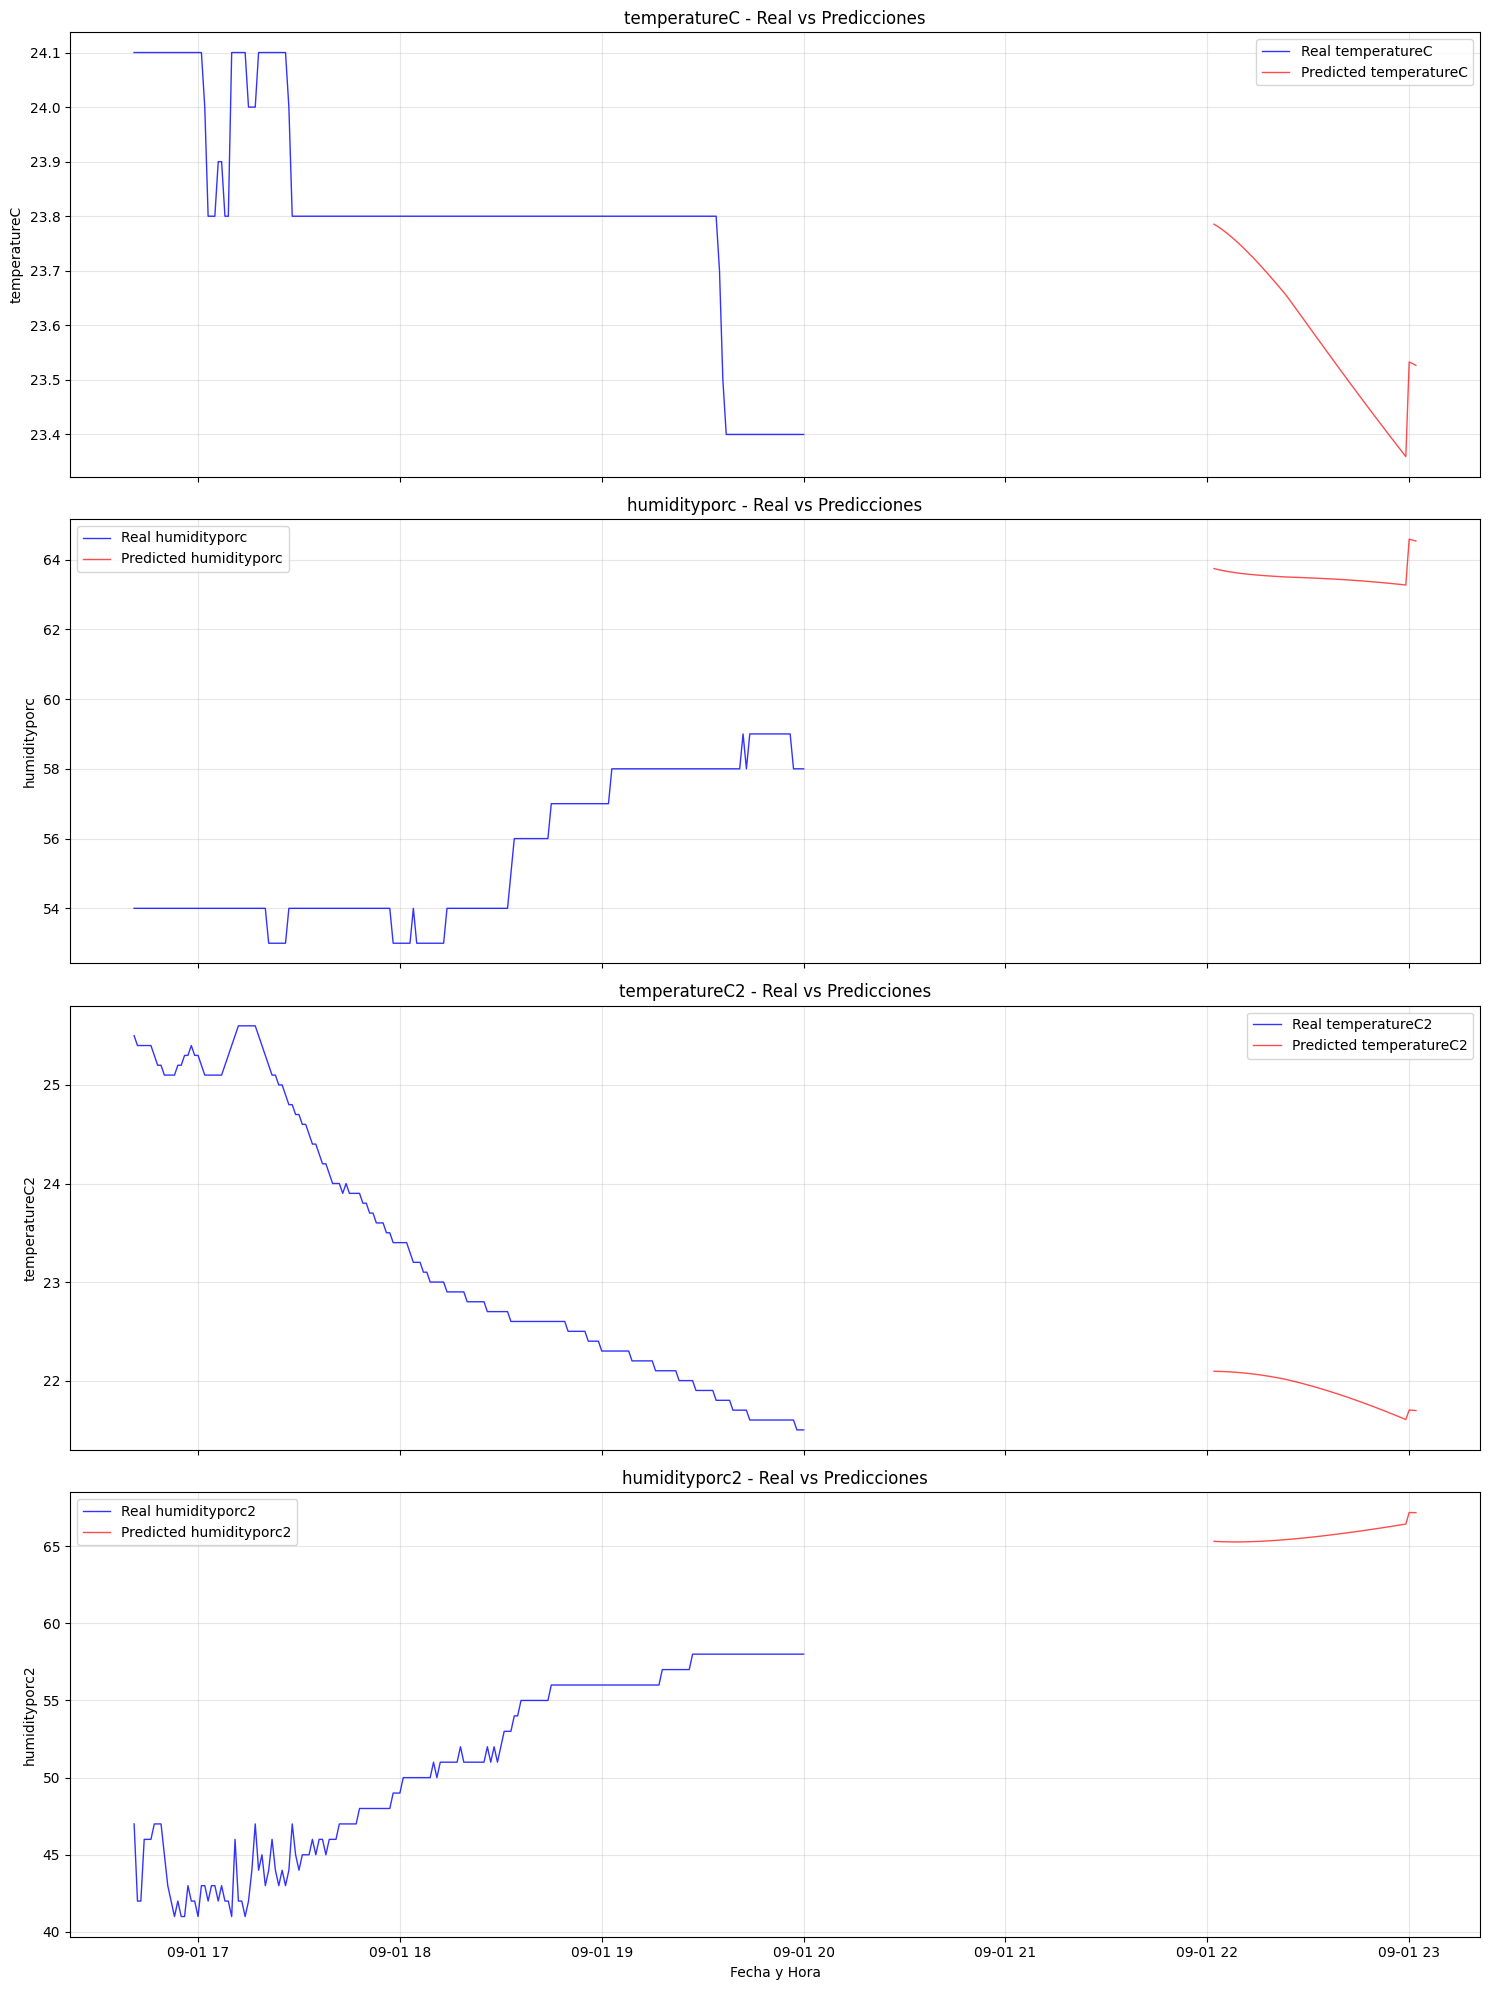

In [5]:
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# FUNCIÓN DE PREDICCIÓN LSTM
# ==============================

def predict_values(date_str, hour, minute):
    """
    Predice las 4 variables de salida dado una fecha/hora.
    Toma los últimos seq_length puntos del dataset original como contexto.
    Retorna array 1D de shape (4,).
    """
    # Construir features de entrada para ese instante
    dt_obj = datetime.strptime(date_str, '%Y-%m-%d')
    single_input = pd.DataFrame([{
        'day':     dt_obj.day,
        'month':   dt_obj.month,
        'year':    dt_obj.year,
        'hours':   hour,
        'minutes': minute,
    }])

    # Repetir el instante seq_length veces para formar la secuencia de contexto
    repeated = pd.concat([single_input] * seq_length, ignore_index=True)
    seq_scaled = scaler_input.transform(repeated[input_features])        # (60, 5)
    seq_scaled = seq_scaled.reshape(1, seq_length, len(input_features))  # (1, 60, 5)

    pred_scaled = final_lstm_model.predict(seq_scaled, verbose=0)        # (1, 4)
    pred_orig   = scaler_output.inverse_transform(pred_scaled)           # (1, 4)
    return pred_orig.flatten()                                           # (4,)

# ==============================
# PREDICCIONES PARA RANGO DE FECHAS
# ==============================

start_date_str = input("Enter the start date for prediction (YYYY-MM-DD): ")
start_hour     = int(input("Enter the start hour for prediction (0-23): "))
start_minute   = int(input("Enter the start minute for prediction (0-59): "))

end_date_str = input("Enter the end date for prediction (YYYY-MM-DD): ")
end_hour     = int(input("Enter the end hour for prediction (0-23): "))
end_minute   = int(input("Enter the end minute for prediction (0-59): "))

start_datetime_pred = datetime.strptime(f"{start_date_str} {start_hour}:{start_minute}", '%Y-%m-%d %H:%M')
end_datetime_pred   = datetime.strptime(f"{end_date_str} {end_hour}:{end_minute}",       '%Y-%m-%d %H:%M')

dates_to_predict_range = pd.date_range(start=start_datetime_pred, end=end_datetime_pred, freq='min')
print(f"Realizando predicciones para {len(dates_to_predict_range)} puntos de tiempo...")

predictions_list = []
for dt in dates_to_predict_range:
    pred = predict_values(dt.strftime('%Y-%m-%d'), dt.hour, dt.minute)  # (4,)
    predictions_list.append(pred)

# Ahora predictions_list es lista de arrays (4,) → stack da (N, 4) ✅
predictions_array = np.vstack(predictions_list)
predictions_df = pd.DataFrame(
    predictions_array,
    index=dates_to_predict_range,
    columns=output_features,
)

print("Predicciones completadas!")

# ==============================
# OBTENER DATOS REALES PARA COMPARACIÓN
# ==============================

last_200_real_data = df[output_features].iloc[-200:].copy()

print(f"Últimos datos reales: desde {last_200_real_data.index[0]} hasta {last_200_real_data.index[-1]}")
print(f"Predicciones:         desde {predictions_df.index[0]} hasta {predictions_df.index[-1]}")

# ==============================
# VISUALIZACIÓN: DATOS REALES VS PREDICCIONES
# ==============================

fig, axes = plt.subplots(len(output_features), 1, figsize=(15, 5 * len(output_features)), sharex=True)

if len(output_features) == 1:
    axes = [axes]

for i, target in enumerate(output_features):
    axes[i].plot(last_200_real_data.index, last_200_real_data[target],
                 label=f'Real {target}', alpha=0.8, linewidth=1, color='blue')
    axes[i].plot(predictions_df.index, predictions_df[target],
                 label=f'Predicted {target}', color='red', alpha=0.7, linewidth=1)
    axes[i].set_title(f'{target} - Real vs Predicciones')
    axes[i].set_ylabel(target)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Fecha y Hora')
plt.tight_layout()
plt.show()

Visualizando los últimos 800 puntos de datos
Rango de fechas: 2025-09-01 06:41:00 a 2025-09-01 20:00:00
Generando predicciones para el subset...
Progreso: 0/800 (0.0%)
Progreso: 100/800 (12.5%)
Progreso: 200/800 (25.0%)
Progreso: 300/800 (37.5%)
Progreso: 400/800 (50.0%)
Progreso: 500/800 (62.5%)
Progreso: 600/800 (75.0%)
Progreso: 700/800 (87.5%)
Predicciones completadas! Shape: (800, 4)


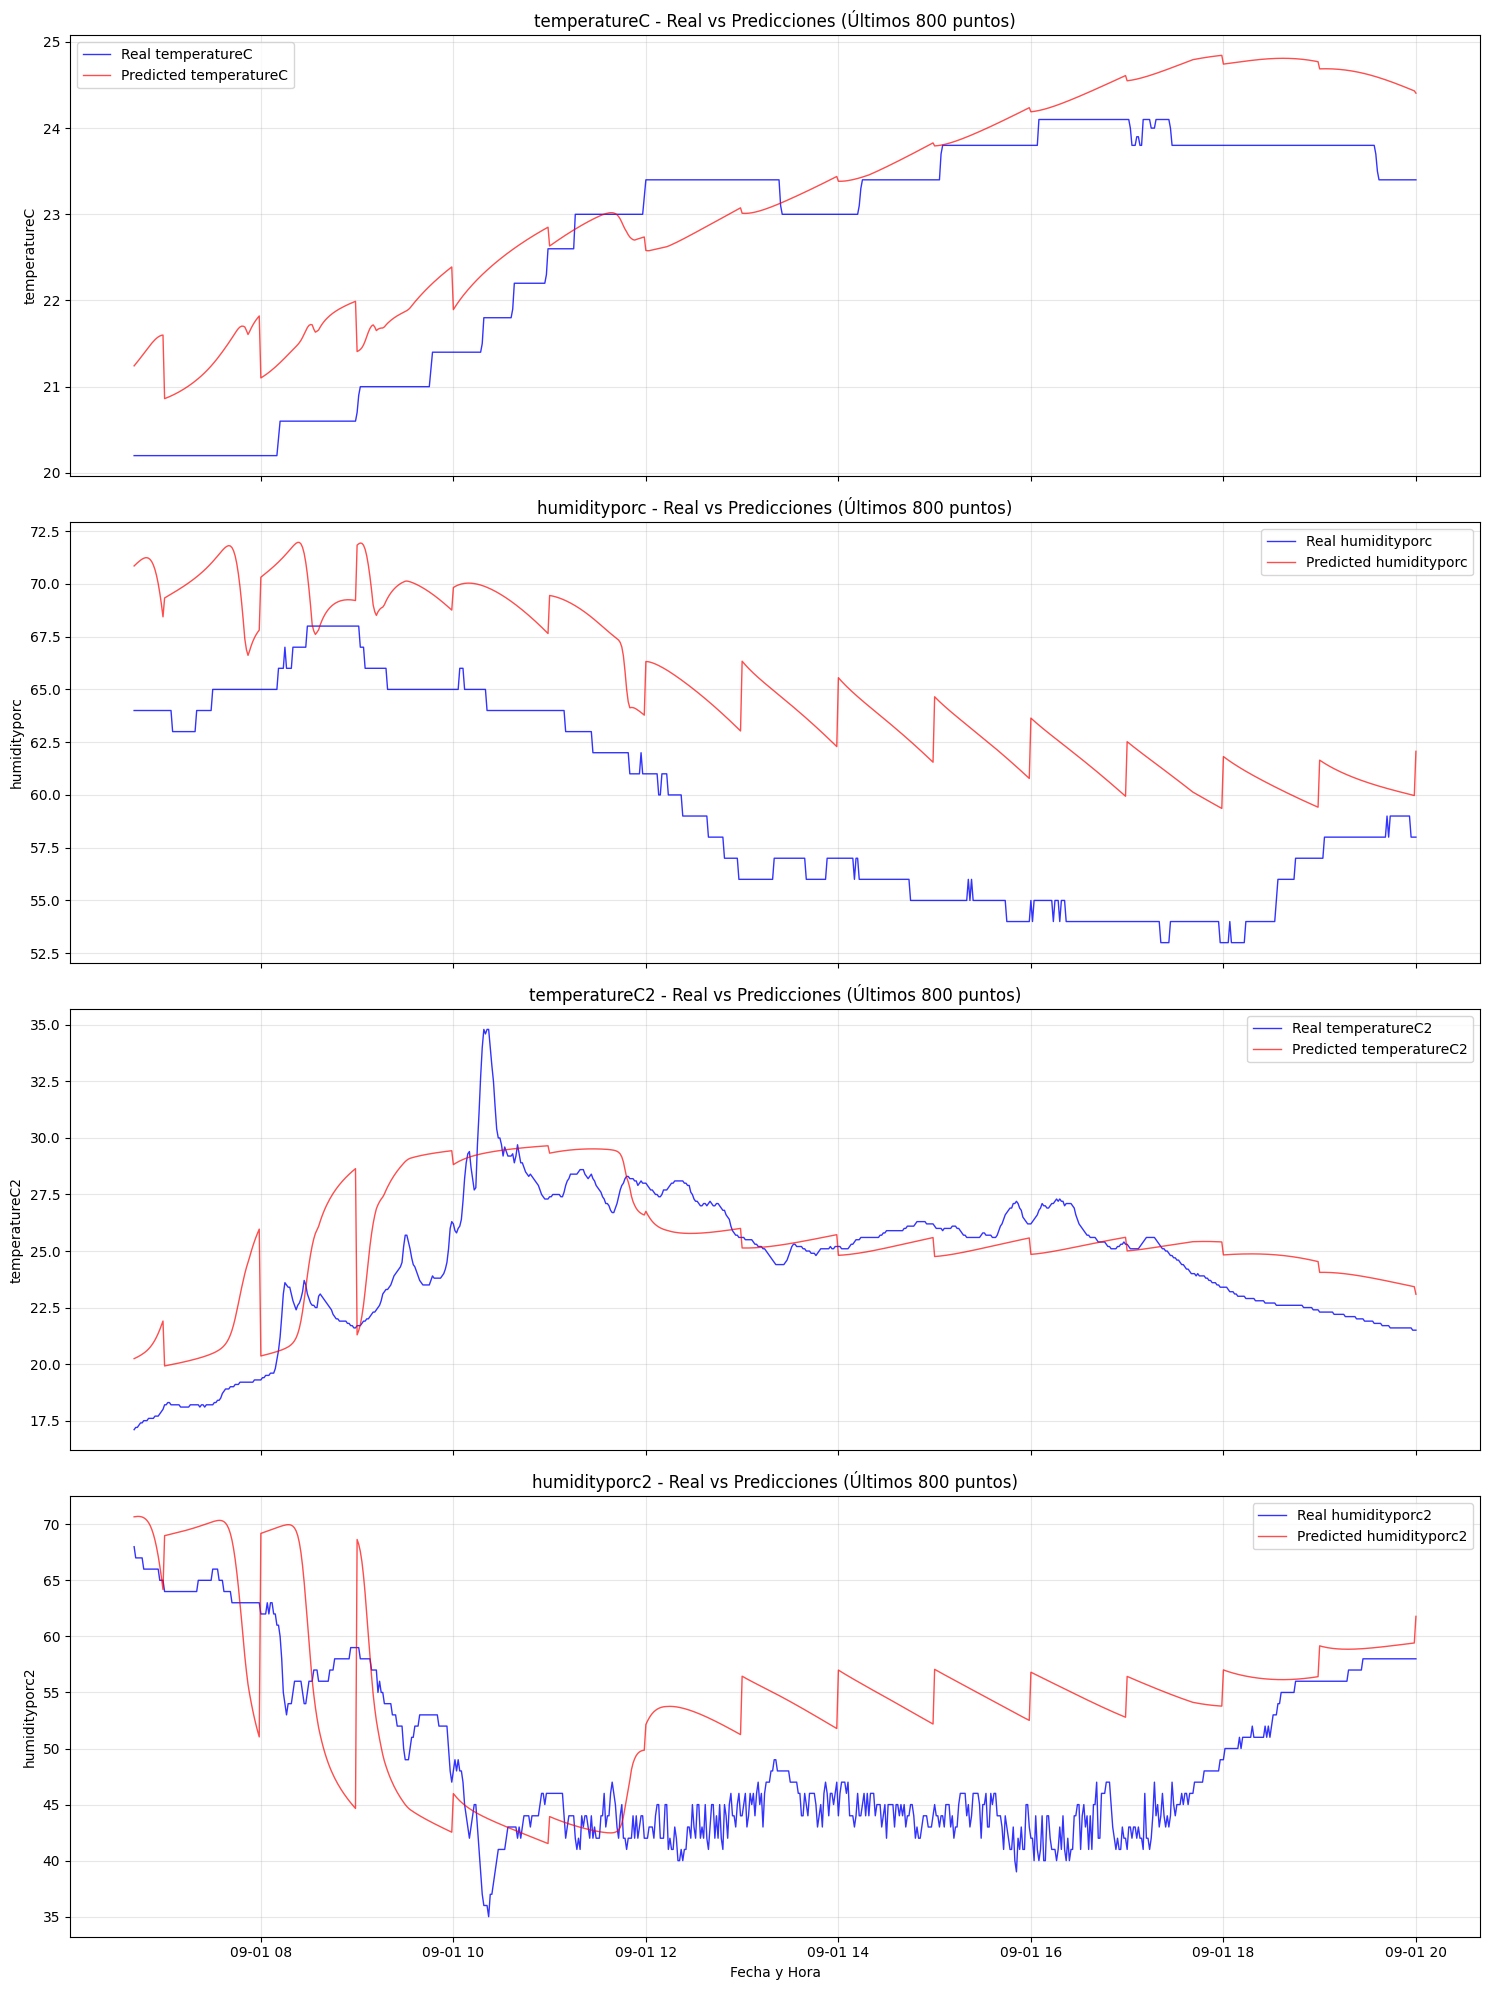

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# ==============================
# VISUALIZACIÓN DE PREDICCIONES VS VALORES REALES (LSTM)
# ==============================

# Select a subset of the data for visualization if it's too large
subset_df = df.iloc[-800:].copy()  # Visualize the last 800 data points
print(f"Visualizando los últimos {len(subset_df)} puntos de datos")
print(f"Rango de fechas: {subset_df.index[0]} a {subset_df.index[-1]}")

# Make predictions for the subset using your predict_values function
print("Generando predicciones para el subset...")

dates_to_predict_subset = subset_df.index
predictions_subset_list = []

# Progress indicator for large datasets
total_predictions = len(dates_to_predict_subset)
for i, dt in enumerate(dates_to_predict_subset):
    # Show progress every 100 predictions
    if i % 100 == 0:
        print(f"Progreso: {i}/{total_predictions} ({i/total_predictions*100:.1f}%)")

    # Extract date components from datetime index
    date_str = dt.strftime('%Y-%m-%d')
    hour = dt.hour
    minute = dt.minute

    # Use your predict_values function
    try:
        prediction = predict_values(date_str, hour, minute)
        predictions_subset_list.append(prediction)
    except Exception as e:
        print(f"Error en predicción para {dt}: {e}")
        # Use previous prediction or zeros as fallback
        if len(predictions_subset_list) > 0:
            predictions_subset_list.append(predictions_subset_list[-1])
        else:
            predictions_subset_list.append([0] * len(output_features))

# Convert predictions to numpy array
predictions_subset = np.array(predictions_subset_list)

print(f"Predicciones completadas! Shape: {predictions_subset.shape}")

# ==============================
# PLOTTING
# ==============================

# Create the visualization
fig, axes = plt.subplots(len(output_features), 1, figsize=(15, 5 * len(output_features)), sharex=True)

# Handle case where there's only one target
if len(output_features) == 1:
    axes = [axes]

# Plot each target
for i, target in enumerate(output_features):
    # Plot real data
    axes[i].plot(subset_df.index, subset_df[target],
                label=f'Real {target}', alpha=0.8, linewidth=1, color='blue')

    # Plot predicted data
    axes[i].plot(dates_to_predict_subset, predictions_subset[:, i],
                label=f'Predicted {target}', color='red', alpha=0.7, linewidth=1)

    axes[i].set_title(f'{target} - Real vs Predicciones (Últimos {len(subset_df)} puntos)')
    axes[i].set_ylabel(target)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Fecha y Hora')
plt.tight_layout()
plt.show()


In [ ]:
! pip install seaborn

EVALUACIÓN DEL MODELO LSTM
Realizando predicciones en conjunto de prueba...
Invirtiendo normalización...
Shape de predicciones: (35413, 4)
Shape de valores reales: (35413, 4)
Número de muestras de prueba: 35413

MÉTRICAS DE RENDIMIENTO

Métricas para temperatureC:
----------------------------------------
  MSE: 2.5334
  RMSE: 1.5917
  MAE: 1.2113
  MAPE: 5.3918%
  R²: -0.2111
  Correlación: 0.8097
  Media real vs pred: 22.3087 vs 23.3571
  Std real vs pred: 1.4463 vs 2.0160

Métricas para humidityporc:
----------------------------------------
  MSE: 173.3683
  RMSE: 13.1669
  MAE: 11.4770
  MAPE: 19.0974%
  R²: -7.0546
  Correlación: 0.3311
  Media real vs pred: 60.0275 vs 49.3688
  Std real vs pred: 4.6394 vs 7.9076

Métricas para temperatureC2:
----------------------------------------
  MSE: 9.6070
  RMSE: 3.0995
  MAE: 2.2905
  MAPE: 10.3045%
  R²: 0.5092
  Correlación: 0.8118
  Media real vs pred: 22.0065 vs 23.4861
  Std real vs pred: 4.4243 vs 4.4541

Métricas para humidityporc2:

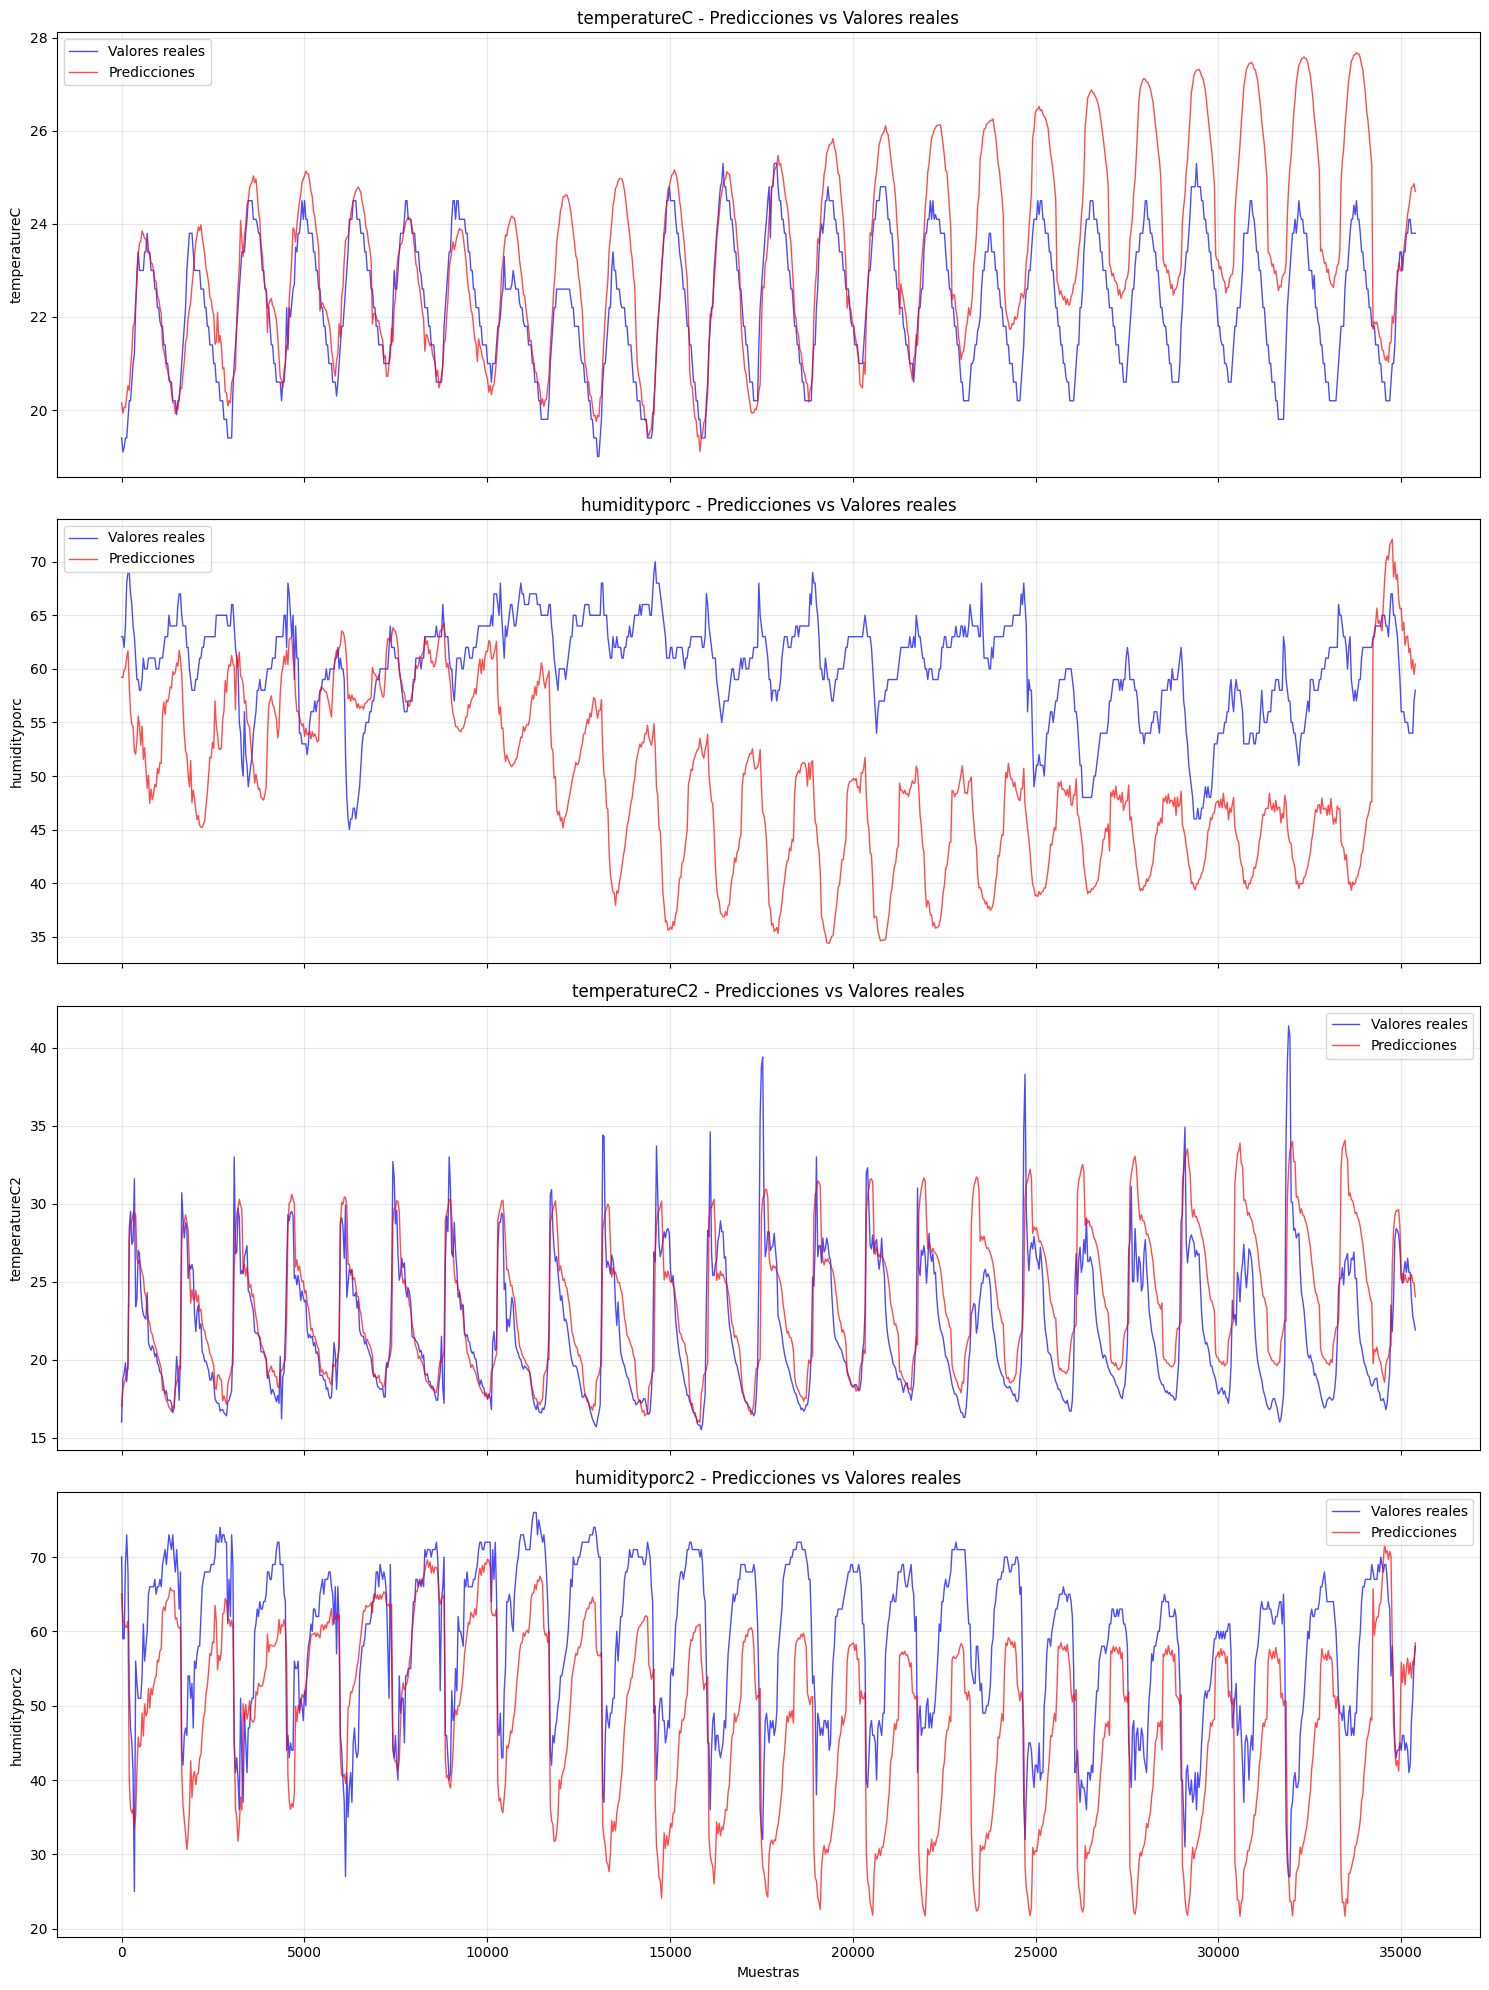

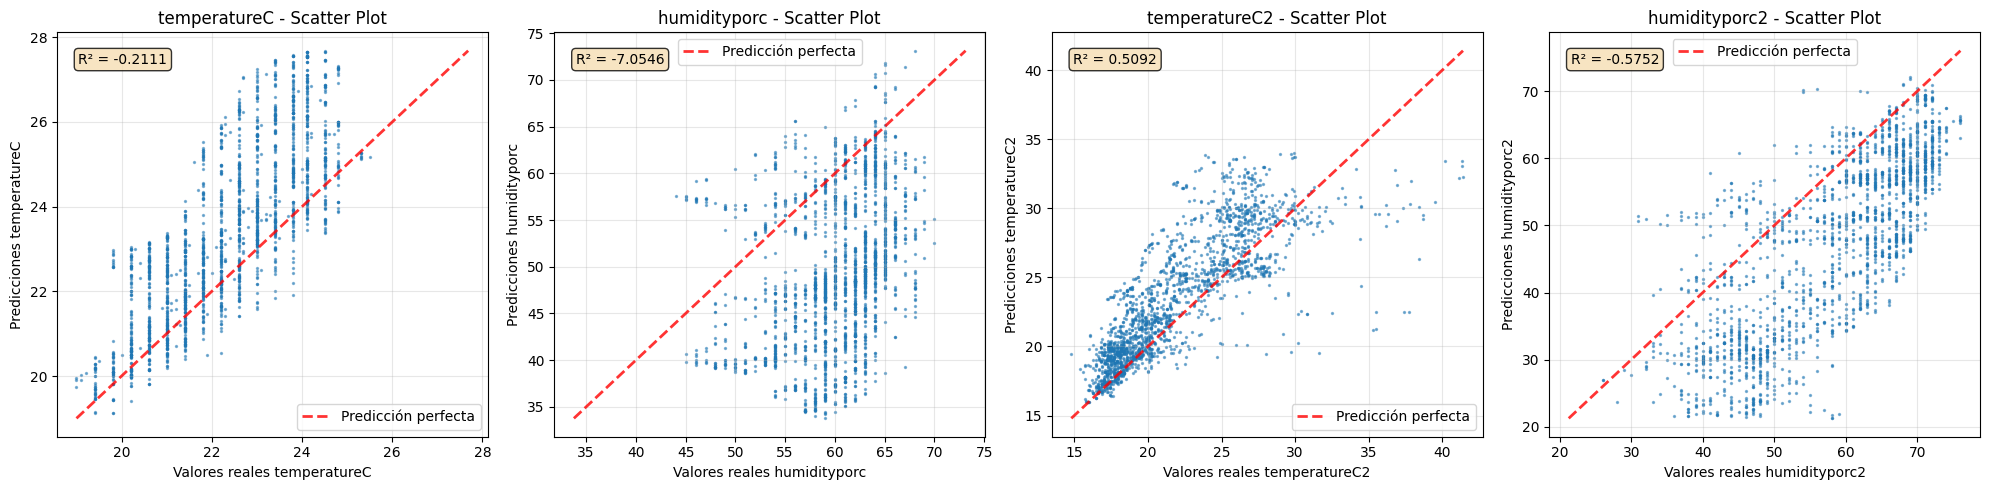

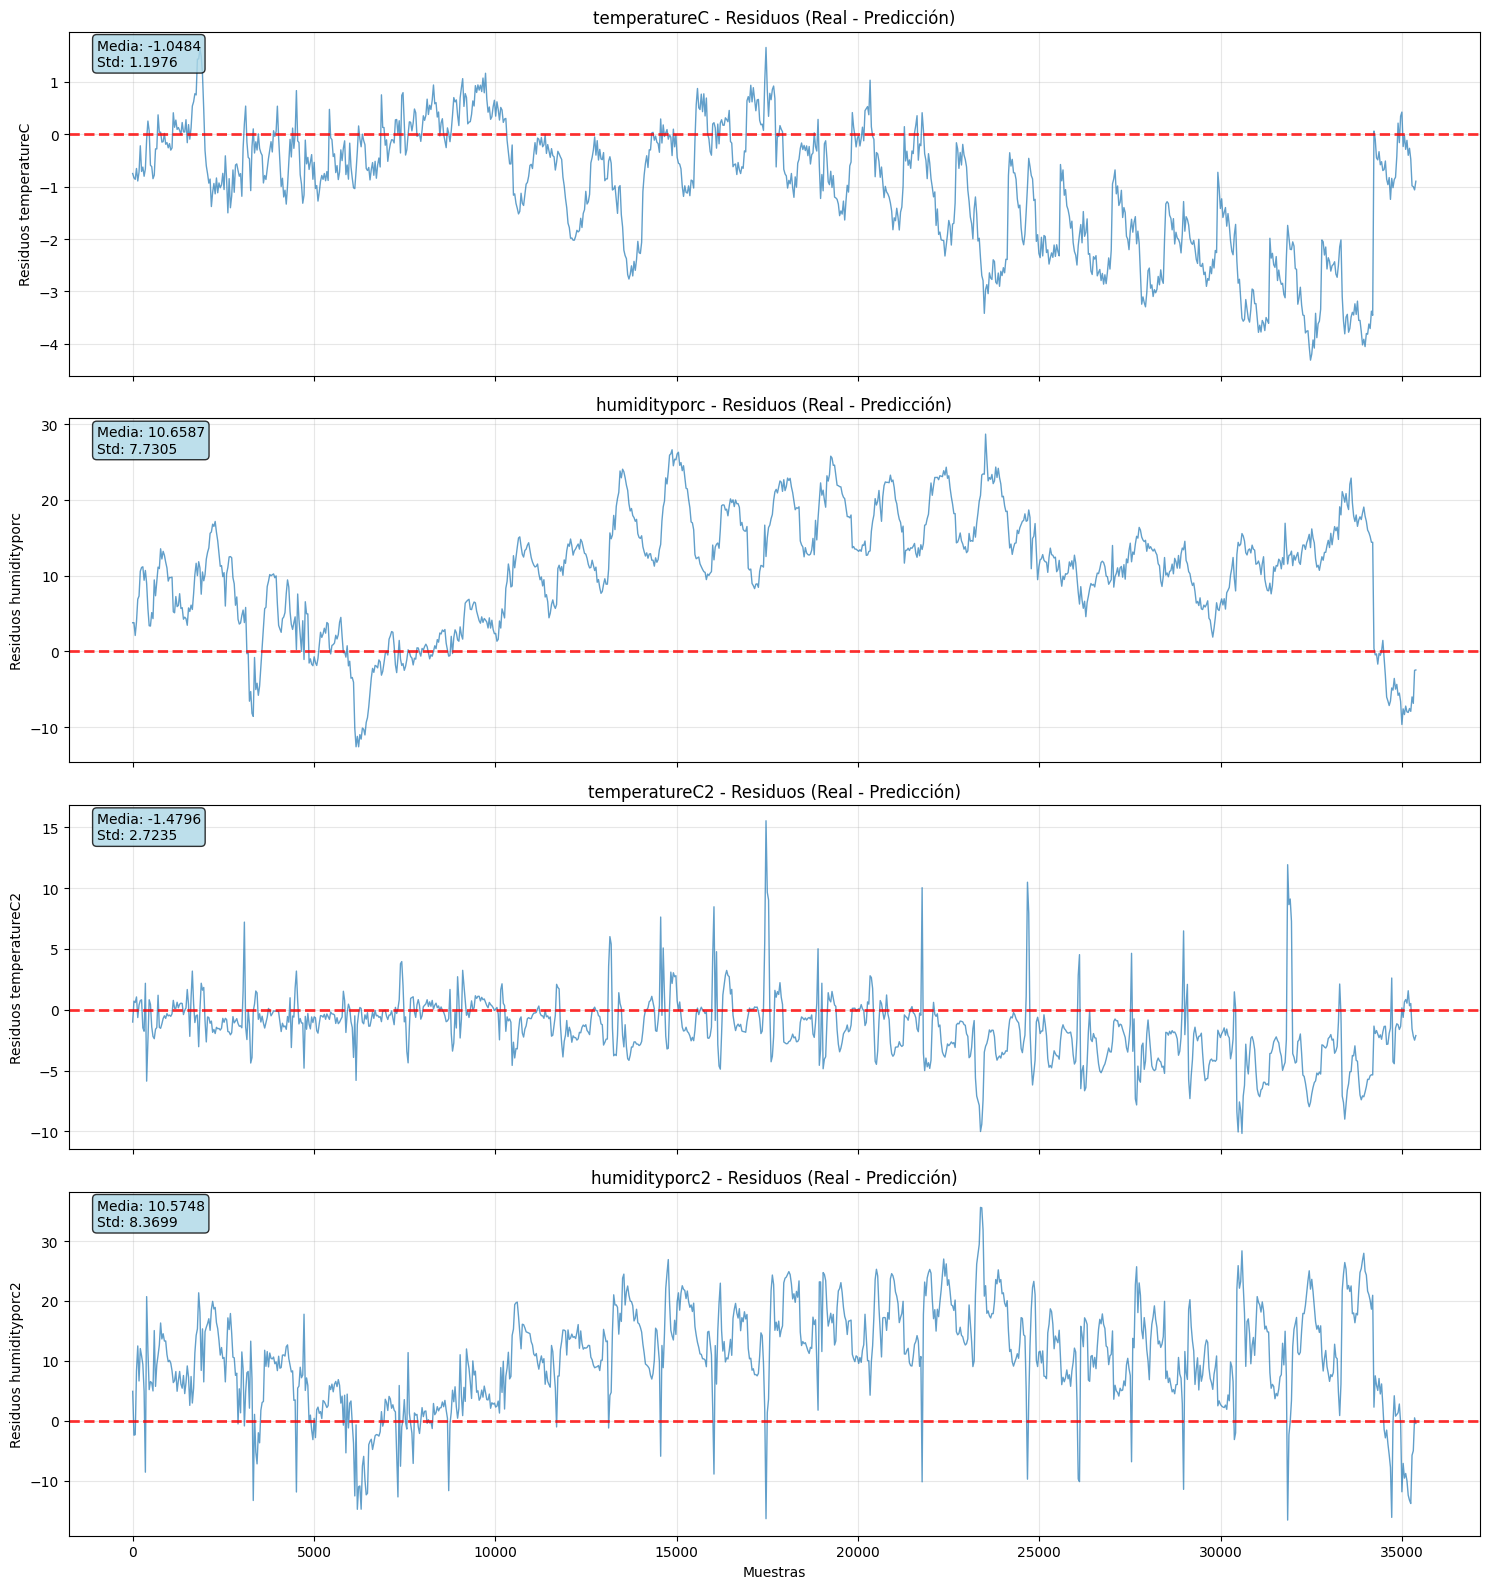

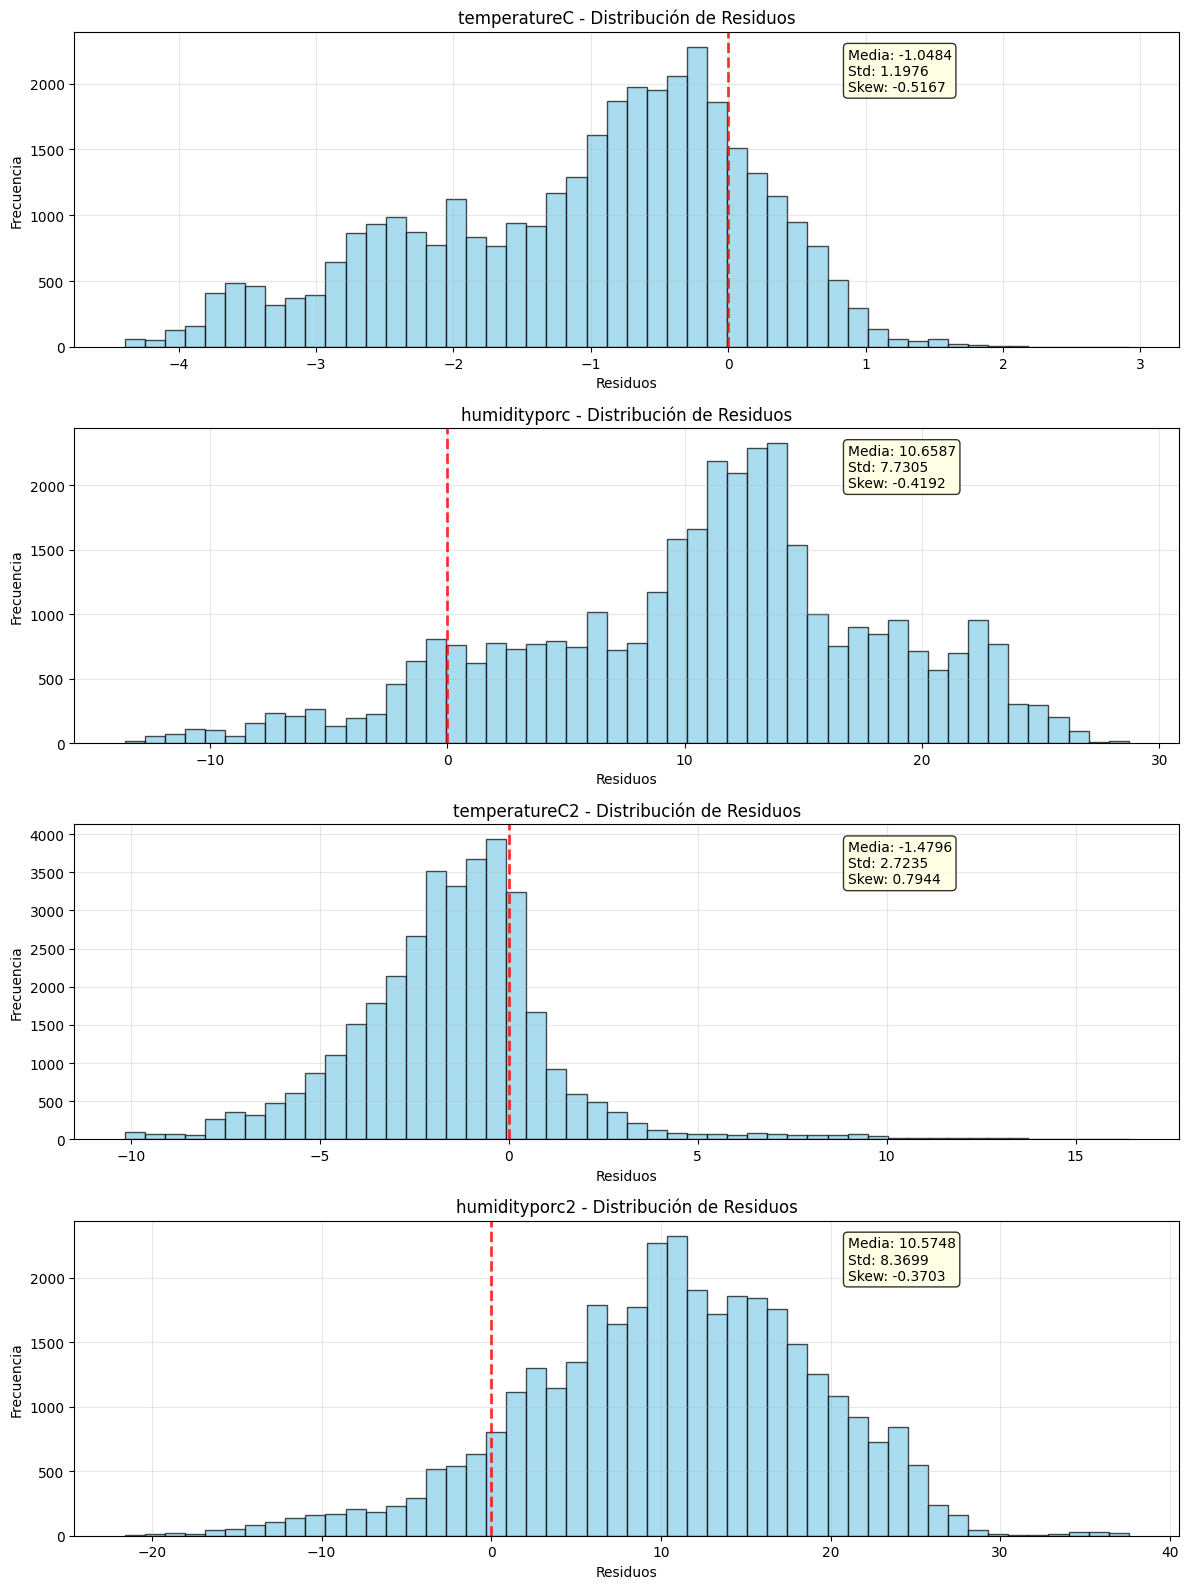

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns

# ==============================
# FUNCIÓN DE EVALUACIÓN MODIFICADA PARA LSTM
# ==============================

def evaluate_model_lstm(model, X_test_input, y_test, scaler_output, output_features):
    """
    Función de evaluación adaptada para modelo LSTM

    Args:
        model: Modelo LSTM entrenado
        X_test_input: Datos de entrada de prueba (shape: samples, seq_length, features)
        y_test: Valores reales de salida (shape: samples, output_features)
        scaler_output: Scaler usado para las variables de salida
        output_features: Lista con nombres de las variables de salida
    """

    print("="*60)
    print("EVALUACIÓN DEL MODELO LSTM")
    print("="*60)

    # Hacer predicciones
    print("Realizando predicciones en conjunto de prueba...")
    y_pred_scaled = final_lstm_model.predict(X_test_input, verbose=0)

    # Invertir la normalización
    print("Invirtiendo normalización...")
    y_pred = scaler_output.inverse_transform(y_pred_scaled)
    y_true = scaler_output.inverse_transform(y_test)

    print(f"Shape de predicciones: {y_pred.shape}")
    print(f"Shape de valores reales: {y_true.shape}")
    print(f"Número de muestras de prueba: {len(y_test)}")

    # ==============================
    # CALCULAR Y MOSTRAR MÉTRICAS
    # ==============================

    print("\n" + "="*60)
    print("MÉTRICAS DE RENDIMIENTO")
    print("="*60)

    metrics_summary = []

    for i, target in enumerate(output_features):
        print(f"\nMétricas para {target}:")
        print("-" * 40)

        # Calcular métricas
        mse = mean_squared_error(y_true[:, i], y_pred[:, i])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])

        # Avoid division by zero in MAPE
        non_zero_mask = y_true[:, i] != 0
        if np.sum(non_zero_mask) > 0:
            mape = np.mean(np.abs((y_true[:, i][non_zero_mask] - y_pred[:, i][non_zero_mask]) /
                                 (y_true[:, i][non_zero_mask] + 1e-8))) * 100
        else:
            mape = float('inf')

        r2 = r2_score(y_true[:, i], y_pred[:, i])

        # Correlación de Pearson
        correlation = np.corrcoef(y_true[:, i], y_pred[:, i])[0, 1]

        # Estadísticas adicionales
        mean_real = np.mean(y_true[:, i])
        mean_pred = np.mean(y_pred[:, i])
        std_real = np.std(y_true[:, i])
        std_pred = np.std(y_pred[:, i])

        print(f"  MSE: {mse:.4f}")
        print(f"  RMSE: {rmse:.4f}")
        print(f"  MAE: {mae:.4f}")
        print(f"  MAPE: {mape:.4f}%")
        print(f"  R²: {r2:.4f}")
        print(f"  Correlación: {correlation:.4f}")
        print(f"  Media real vs pred: {mean_real:.4f} vs {mean_pred:.4f}")
        print(f"  Std real vs pred: {std_real:.4f} vs {std_pred:.4f}")

        # Guardar métricas para resumen
        metrics_summary.append({
            'Variable': target,
            'MSE': mse,
            'RMSE': rmse,
            'MAE': mae,
            'MAPE': mape,
            'R²': r2,
            'Correlación': correlation
        })

    # ==============================
    # TABLA RESUMEN DE MÉTRICAS
    # ==============================

    metrics_df = pd.DataFrame(metrics_summary)
    print(f"\n" + "="*60)
    print("TABLA RESUMEN DE MÉTRICAS")
    print("="*60)
    print(metrics_df.round(4))

    # ==============================
    # GRÁFICA 1: PREDICCIONES VS VALORES REALES
    # ==============================

    fig, axes = plt.subplots(len(output_features), 1, figsize=(15, 5 * len(output_features)), sharex=True)

    if len(output_features) == 1:
        axes = [axes]

    for i, target in enumerate(output_features):
        # Crear índices para mejor visualización
        sample_indices = np.arange(len(y_true[:, i]))

        # Plot solo una muestra si hay muchos datos
        max_samples = 1000
        if len(sample_indices) > max_samples:
            step = len(sample_indices) // max_samples
            sample_indices = sample_indices[::step]

        axes[i].plot(sample_indices, y_true[sample_indices, i],
                    label='Valores reales', alpha=0.7, linewidth=1, color='blue')
        axes[i].plot(sample_indices, y_pred[sample_indices, i],
                    label='Predicciones', alpha=0.7, linewidth=1, color='red')
        axes[i].set_title(f'{target} - Predicciones vs Valores reales')
        axes[i].set_ylabel(target)
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

    axes[-1].set_xlabel('Muestras')
    plt.tight_layout()
    plt.show()

    # ==============================
    # GRÁFICA 2: SCATTER PLOTS
    # ==============================

    fig, axes = plt.subplots(1, len(output_features), figsize=(5 * len(output_features), 5))

    if len(output_features) == 1:
        axes = [axes]

    for i, target in enumerate(output_features):
        # Scatter plot con sample si hay muchos puntos
        if len(y_true) > 2000:
            sample_idx = np.random.choice(len(y_true), 2000, replace=False)
            x_scatter = y_true[sample_idx, i]
            y_scatter = y_pred[sample_idx, i]
        else:
            x_scatter = y_true[:, i]
            y_scatter = y_pred[:, i]

        axes[i].scatter(x_scatter, y_scatter, alpha=0.5, s=2)

        # Línea de predicción perfecta
        min_val = min(np.min(x_scatter), np.min(y_scatter))
        max_val = max(np.max(x_scatter), np.max(y_scatter))
        axes[i].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.8, linewidth=2,
                    label='Predicción perfecta')

        axes[i].set_xlabel(f'Valores reales {target}')
        axes[i].set_ylabel(f'Predicciones {target}')
        axes[i].set_title(f'{target} - Scatter Plot')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

        # Añadir R² en el gráfico
        r2_val = r2_score(y_true[:, i], y_pred[:, i])
        axes[i].text(0.05, 0.95, f'R² = {r2_val:.4f}',
                    transform=axes[i].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.show()

    # ==============================
    # GRÁFICA 3: RESIDUOS
    # ==============================

    fig, axes = plt.subplots(len(output_features), 1, figsize=(15, 4 * len(output_features)), sharex=True)

    if len(output_features) == 1:
        axes = [axes]

    for i, target in enumerate(output_features):
        residuals = y_true[:, i] - y_pred[:, i]

        # Plot residuos
        sample_indices = np.arange(len(residuals))
        if len(sample_indices) > 1000:
            step = len(sample_indices) // 1000
            sample_indices = sample_indices[::step]

        axes[i].plot(sample_indices, residuals[sample_indices], alpha=0.7, linewidth=1)
        axes[i].axhline(y=0, color='r', linestyle='--', alpha=0.8, linewidth=2)
        axes[i].set_title(f'{target} - Residuos (Real - Predicción)')
        axes[i].set_ylabel(f'Residuos {target}')
        axes[i].grid(True, alpha=0.3)

        # Estadísticas de residuos
        mean_residual = np.mean(residuals)
        std_residual = np.std(residuals)
        axes[i].text(0.02, 0.98, f'Media: {mean_residual:.4f}\nStd: {std_residual:.4f}',
                    transform=axes[i].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

    axes[-1].set_xlabel('Muestras')
    plt.tight_layout()
    plt.show()

    # ==============================
    # GRÁFICA 4: HISTOGRAMA DE RESIDUOS
    # ==============================

    fig, axes = plt.subplots(len(output_features), 1, figsize=(12, 4 * len(output_features)), sharex=False)

    if len(output_features) == 1:
        axes = [axes]

    for i, target in enumerate(output_features):
        residuals = y_true[:, i] - y_pred[:, i]

        # Histograma
        axes[i].hist(residuals, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
        axes[i].axvline(x=0, color='r', linestyle='--', linewidth=2, alpha=0.8)
        axes[i].set_title(f'{target} - Distribución de Residuos')
        axes[i].set_xlabel('Residuos')
        axes[i].set_ylabel('Frecuencia')
        axes[i].grid(True, alpha=0.3)

        # Estadísticas en el gráfico
        mean_res = np.mean(residuals)
        std_res = np.std(residuals)
        axes[i].text(0.7, 0.95, f'Media: {mean_res:.4f}\nStd: {std_res:.4f}\nSkew: {pd.Series(residuals).skew():.4f}',
                    transform=axes[i].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

    plt.tight_layout()
    plt.show()


    # ==============================
    # RETORNAR MÉTRICAS PARA USO POSTERIOR
    # ==============================

    return {
        'y_true': y_true,
        'y_pred': y_pred,
        'metrics_df': metrics_df,
        'residuals': {target: y_true[:, i] - y_pred[:, i] for i, target in enumerate(output_features)}
    }

# ==============================
# FUNCIÓN DE EVALUACIÓN SIMPLIFICADA
# ==============================

def quick_evaluate(final_lstm_model, X_test_final, y_test_final, scaler_output, output_features):
    """Evaluación rápida solo con métricas numéricas"""

    y_pred_scaled = final_lstm_model.predict(X_test_final, verbose=0)
    y_pred = scaler_output.inverse_transform(y_pred_scaled)
    y_true = scaler_output.inverse_transform(y_test_final)

    print("EVALUACIÓN RÁPIDA")
    print("="*40)

    for i, target in enumerate(output_features):
        rmse = np.sqrt(mean_squared_error(y_true[:, i], y_pred[:, i]))
        mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
        r2 = r2_score(y_true[:, i], y_pred[:, i])

        print(f"{target}: RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")

# ==============================
# USO DE LA FUNCIÓN
# ==============================

# Evaluar el modelo LSTM (usando las variables de tu código original)
results = evaluate_model_lstm(final_lstm_model, X_test_final, y_test_final, scaler_output, output_features)

# O para evaluación rápida:
# quick_evaluate(model, X_test_input, y_test, scaler_output, output_features)